In [1]:
!rm metadata_.json
!rm metadata_2.json

In [2]:
!pip install sdv
!pip install sdmetrics
!pip install nbformat


In [3]:
import pandas as pd
my_df = pd.read_csv("adult-data-census.csv",index_col=0)

In [4]:
df_reset = my_df.reset_index()


In [5]:
import numpy as np
df_reset = df_reset.replace('^ ', '', regex=True)
df_reset = df_reset.replace('?', np.nan)


In [6]:
null_values = df_reset.isnull().sum(axis=1)
for i in range(3):
    null_values = list(filter(lambda x: x > i, null_values))
    


In [7]:
df_reset.columns = list(map(lambda x: x.replace(" ", ""), df_reset.columns))

In [8]:
df_reset.columns = list(map(lambda x: x.replace("-", "_"), df_reset.columns))

In [9]:
df_reset_copy = df_reset.dropna()

In [10]:
columns_values = df_reset_copy.columns

In [11]:
is_col_continuos = []
is_col_categorical = []
is_col_categorical_many_examples = []
is_col_discrete = []
is_col_ordinal = []
import math

for elements_cols in df_reset_copy.columns:
    give_exception = False
    if ".float" in str(type(df_reset_copy.at[0, elements_cols])):
        give_exception = True
        for idx in range(len(df_reset_copy[elements_cols])):
            if 'float' in str(type(df_reset_copy.loc[idx, elements_cols])) and math.isnan(df_reset_copy.loc[idx, elements_cols]):
                continue
            give_exception = df_reset_copy.loc[idx, elements_cols] == float(int(df_reset_copy.loc[idx, elements_cols]))
            if give_exception == False:
                break
        if give_exception and df_reset_copy[elements_cols].nunique() < 20:
            is_col_categorical.append(elements_cols)
        elif give_exception and df_reset_copy[elements_cols].nunique() < 50:
            is_col_categorical_many_examples.append(elements_cols)
        else:
            is_col_continuos.append(elements_cols)
    
    elif df_reset_copy[elements_cols].nunique() < 20:
        is_col_categorical.append(elements_cols)
    elif df_reset_copy[elements_cols].nunique() < 50:
        is_col_categorical_many_examples.append(elements_cols)
    elif ".int" in str(type(df_reset_copy.at[0, elements_cols])):
        is_col_discrete.append(elements_cols)
    else:
        is_col_ordinal.append(elements_cols)


In [12]:
df_reset_copy_ = df_reset.copy()

Here we try to reduce the number of unique values from categorical columns, we will replace rare values with 'Others' to reduce balance the dataset.

In [13]:
from collections import Counter
for col_cat in is_col_categorical_many_examples:
    frequency_el = Counter(df_reset_copy[col_cat])
    d = dict(frequency_el)
    d = dict(sorted(d.items(), key=lambda key_val: key_val[1], reverse=True))
    val_len = len(df_reset_copy[col_cat])
    val = 0
    d_new = {}
    for idx, el in enumerate(d):
        val+= d[el]
        d_new[el] = d[el]
        if val > val_len * 0.98:
            break
    
    for nationality in df_reset_copy_[col_cat].unique():
        if nationality not in d_new.keys():
            df_reset_copy_.loc[df_reset_copy_[col_cat]==nationality, col_cat] = 'Others'
            df_reset_copy_.loc[df_reset_copy_[col_cat]==nationality, col_cat] = 'Others'
    is_col_categorical_many_examples.remove(col_cat)
    is_col_categorical.append(col_cat)


In [14]:
cols_to_ignore = []
for cols in df_reset_copy_.columns:
    columns_filtered = list(filter(lambda x: cols in x and cols!=x, df_reset_copy_.columns)) 
    if columns_filtered == []:
        continue
    for extr_column in columns_filtered: 
        extr_column_2 = extr_column
        extr_column = extr_column.replace(cols, "")
        if "num" in extr_column or "numeric" in extr_column:
            #df_reset_copy_ = df_reset_copy_.drop(cols, axis=1)
            is_col_ordinal.append(extr_column_2)
            is_col_categorical.remove(extr_column_2)
            cols_to_ignore.append(cols)
            is_col_categorical.remove(cols)
            break


In [15]:
is_col_OH =is_col_categorical.copy()
for col_val in is_col_categorical:
    if ".int" in str(type(df_reset_copy_.at[0, col_val])) or ".float" in str(type(df_reset_copy_.at[0, col_val])):
        is_col_OH.remove(col_val)
    

In [16]:
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder(sparse_output=False)
one_hot_encoded = encoder.fit_transform(df_reset_copy[is_col_OH])
one_hot_df = pd.DataFrame(one_hot_encoded,  columns=encoder.get_feature_names_out(is_col_OH))
df_reset_copy = pd.concat([df_reset_copy.drop(is_col_OH, axis=1), one_hot_df], axis=1)

!NEED TO OPTIMIZE HERE, MAYBE USE MATRIX MULTIPLICATION INSTEAD

In [17]:
# THESE TERMS ARE PROTECTED AND CLASSIFIED AS SENSITIVE UNDER THE US EEOC
list_of_sensitive_words = ['race', 'color', 'religion', 'sex', 'gender', 'age', 'disability', 'country', 'region', 'country_of_origin', 'native_country', 'salary']

In [18]:
from common_functions_f__ import generate_embedings_index
import numpy as np
embeddings_index =  generate_embedings_index()

In [19]:
import faiss
list_of_sensitive_embeddings = np.array([embeddings_index[word] for word in list_of_sensitive_words], dtype=np.float32, order='C')
faiss.normalize_L2(list_of_sensitive_embeddings)

In [20]:
from scipy.stats import chi2_contingency
correlated_values_2 = {}
correlated_values_3 = {}

highest_corr_values = []
correlated_columns = set()
value_cosine_similarity = {}
for idx_col_cat in range(len(is_col_categorical)):

    for idx_col_cat_2 in range(idx_col_cat+1, len(is_col_categorical)):
        col_cat = is_col_categorical[idx_col_cat]
        
        col_cat_2 = is_col_categorical[idx_col_cat_2]
        
        contingency_table = pd.crosstab(df_reset_copy_[col_cat], df_reset_copy_[col_cat_2])
        chi2_statistic, p_value, dof, expected = chi2_contingency(contingency_table)
        n = contingency_table.sum().sum()
        phi2 = chi2_statistic / n
        r, k = contingency_table.shape
        if n == 1:
            v = 0
        else: 
            phi2corr = max(0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
            k_corr = k - (k - 1) * (k - 2) / (n - 1)
            r_corr = r - (r - 1) * (r - 2) / (n - 1)
            if k_corr == 1 and r_corr == 1:
                v = 0
            elif k_corr != 1 and r_corr==1:
                v = np.sqrt(phi2corr/(k_corr-1))
            elif r_corr != 1 and k_corr == 1:
                v = np.sqrt(phi2corr/(r_corr-1))
            else:
                v = np.sqrt(phi2corr / min(k_corr - 1, r_corr - 1))
        if col_cat not in value_cosine_similarity.keys():
            if col_cat in embeddings_index.keys():
                embedding_word = np.array([embeddings_index[col_cat]], dtype=np.float32, order='C')
                faiss.normalize_L2(embedding_word)
                values = np.einsum('jk,lk->jl', embedding_word, list_of_sensitive_embeddings)
            else:
                sp_word = ""
                for i in range(len(col_cat)):
                    word = list(filter(lambda x: x.startswith(col_cat[0:i]) and x.endswith(col_cat[i+1:]), embeddings_index.keys()))
                    if len(word) > 0:
                        sp_word = word[0]
                        break

                embedding_word = np.array([embeddings_index[sp_word]], dtype=np.float32, order='C')
                faiss.normalize_L2(embedding_word)
                values = np.einsum('jk,lk->jl', embedding_word, list_of_sensitive_embeddings)
            values = np.max(values)
            value_cosine_similarity[col_cat] = values
        else:
            values = value_cosine_similarity[col_cat]

        if col_cat_2 not in value_cosine_similarity.keys():
            if col_cat_2 in embeddings_index.keys():
                embedding_word_2 = np.array([embeddings_index[col_cat_2]], dtype=np.float32, order='C')
                faiss.normalize_L2(embedding_word_2)
                values_2 = np.einsum('jk,lk->jl', embedding_word_2, list_of_sensitive_embeddings)
            else:
                sp_word = ""
                for i in range(len(col_cat)):
                    word = list(filter(lambda x: x.startswith(col_cat[0:i]) and x.endswith(col_cat[i+1:]), embeddings_index.keys()))
                    if len(word) > 0:
                        sp_word = word[0]
                        break

                embedding_word = np.array([embeddings_index[sp_word]], dtype=np.float32, order='C')
                faiss.normalize_L2(embedding_word)
                values_2 = np.einsum('jk,lk->jl', embedding_word, list_of_sensitive_embeddings)
            values_2 = np.max(values_2)
            value_cosine_similarity[col_cat_2] = values_2
        else:
            values_2 = value_cosine_similarity[col_cat_2]

        

        if v < 0.5 and (values > 0.5 or values_2 > 0.5):
            continue

        
        if v > 0.35:
            
            if (col_cat, col_cat_2) not in correlated_columns or (col_cat_2, col_cat) not in correlated_columns:
                correlated_columns.add((col_cat, col_cat_2))
            if col_cat in correlated_values_2.keys():
                list_cat = correlated_values_2[col_cat]
                list_cat_2 = correlated_values_3[col_cat]
                list_cat.append((float(v), col_cat_2))
                list_cat_2.append(col_cat_2)
                correlated_values_2[col_cat] = list_cat
                correlated_values_3[col_cat] = list_cat_2

            else:
                correlated_values_2[col_cat] = [(float(v), col_cat_2)]
                correlated_values_3[col_cat] = [col_cat_2]
            
            if col_cat_2 in correlated_values_2.keys():
                list_cat = correlated_values_2[col_cat_2]
                list_cat_2 = correlated_values_3[col_cat_2]
                list_cat.append((float(v), col_cat))
                list_cat_2.append(col_cat)
                correlated_values_2[col_cat_2] = list_cat
                correlated_values_3[col_cat_2] = list_cat_2
            else:
                correlated_values_2[col_cat_2] = [(float(v), col_cat)]
                correlated_values_3[col_cat_2] = [col_cat]
      

In [21]:
from scipy.stats import chi2_contingency
from sklearn.preprocessing import LabelEncoder

cramer_values = {}
from scipy.stats import pearsonr
value_with_target = {}
is_col_numeric = is_col_discrete.copy()
is_col_numeric.extend(is_col_continuos)
for col_num_idx in range(len(is_col_numeric)-1):
    for col_num2_idx in range(col_num_idx+1, len(is_col_numeric)):
        col_num = is_col_numeric[col_num_idx]
        col_num2 = is_col_numeric[col_num2_idx]
        corr, _ = pearsonr(df_reset_copy_[col_num], df_reset_copy_[col_num2])
        if abs(corr) > 0.5:
            if col_num in correlated_values_3.keys():
                list_cat_2 = correlated_values_3[col_num]
                list_cat_2.append(col_num2)
                correlated_values_3[col_num] = list_cat_2

            else:
                correlated_values_3[col_num] = [col_num2]
            
            if col_num2 in correlated_values_3.keys():
                list_cat_2 = correlated_values_3[col_num2]
                list_cat_2.append(col_num)
                correlated_values_3[col_num2] = list_cat_2
            else:
                correlated_values_3[col_num2] = [col_num]
            



THERE WERE PROBLEMATIC ASSOCIATION BETWEEN SEX AND OCCUPATION, LATER FOR EXAMPLE, WE FOUND That in this dataset, there are no woman in the armed forces, but it is not an impossible situation like the "Unmarried" and "Husband" association, so we try to exclude moderate correlations associations related to sex or gender, in order to avoid bias in the dataset.

In [22]:
for key_ in correlated_values_2.keys():
    list_cat = correlated_values_2[key_]
    list_cat.sort(key=lambda x: x[0], reverse=True)
    correlated_values_2[key_] = list_cat

In [23]:
import statsmodels.api as sm
from statsmodels.formula.api import ols
for col_cat in is_col_categorical:
    is_col_numeric = is_col_discrete

    for col_num in is_col_numeric:
        
        model = ols(f'{col_num} ~ {col_cat}',data = df_reset_copy_).fit()
                
        anova_result = sm.stats.anova_lm(model, typ=2)
        eta_2 = anova_result['sum_sq'][col_cat]/(anova_result['sum_sq'][col_cat] + anova_result['sum_sq']['Residual'])

        if col_cat not in value_cosine_similarity.keys():
            if col_cat in embeddings_index.keys():
                embedding_word = np.array([embeddings_index[col_cat]], dtype=np.float32, order='C')
                faiss.normalize_L2(embedding_word)
                values = np.einsum('jk,lk->jl', embedding_word, list_of_sensitive_embeddings)
            else:
                sp_word = ""
                for i in range(len(col_cat)):
                    word = list(filter(lambda x: x.startswith(col_cat[0:i]) and x.endswith(col_cat[i+1:]), embeddings_index.keys()))
                    if len(word) > 0:
                        sp_word = word[0]
                        break

                embedding_word = np.array([embeddings_index[sp_word]], dtype=np.float32, order='C')
                faiss.normalize_L2(embedding_word)
                values = np.einsum('jk,lk->jl', embedding_word, list_of_sensitive_embeddings)
            values = np.max(values)
            value_cosine_similarity[col_cat] = values
        else:
            values = value_cosine_similarity[col_cat]

        if col_cat_2 not in value_cosine_similarity.keys():
            if col_cat_2 in embeddings_index.keys():
                embedding_word_2 = np.array([embeddings_index[col_cat_2]], dtype=np.float32, order='C')
                faiss.normalize_L2(embedding_word_2)
                values_2 = np.einsum('jk,lk->jl', embedding_word_2, list_of_sensitive_embeddings)
            else:
                sp_word = ""
                for i in range(len(col_cat)):
                    word = list(filter(lambda x: x.startswith(col_cat[0:i]) and x.endswith(col_cat[i+1:]), embeddings_index.keys()))
                    if len(word) > 0:
                        sp_word = word[0]
                        break

                embedding_word = np.array([embeddings_index[sp_word]], dtype=np.float32, order='C')
                faiss.normalize_L2(embedding_word)
                values_2 = np.einsum('jk,lk->jl', embedding_word, list_of_sensitive_embeddings)
            values_2 = np.max(values_2)
            value_cosine_similarity[col_cat_2] = values_2
        else:
            values_2 = value_cosine_similarity[col_cat_2]


    
        if (values > 0.5 or values_2 > 0.5) and eta_2 < 0.35:
            continue

        if eta_2 > 0.16:

            if col_cat in correlated_values_3.keys():
                list_cat_2 = correlated_values_3[col_cat]
                list_cat_2.append(col_num)
                correlated_values_3[col_cat] = list_cat_2

            else:
                correlated_values_3[col_cat] = [col_num]
            
            if col_num in correlated_values_3.keys():
                list_cat_2 = correlated_values_3[col_num]
                list_cat_2.append(col_cat)
                correlated_values_3[col_num] = list_cat_2
            else:
                correlated_values_3[col_num] = [col_cat]


The high correlations are related to columns which do not have missing values

There are low correlations between the columns in the dataset, which suggests that the each feature is not correlated with the other, so the inputting must be done in a generalised manner, or through intuition. So there is no need for eliminating columns.

In [24]:
are_missing_values = []
for idx, values in enumerate(df_reset.isnull().sum()):
    if values > 0:
        are_missing_values.append(df_reset.columns[idx])

In [25]:
null_values = df_reset_copy_.isnull().sum(axis=1)
null_values = list(map(lambda x: x[0], list(filter(lambda x: x[1] > i, zip(list(null_values.index), null_values)))))

df_reset_copy_ = df_reset_copy_.drop(null_values)

In [26]:
import warnings
warnings.filterwarnings(
    action='ignore', category=UserWarning, message=r"Boolean Series.*"
)


In [27]:
correlated_dict_ = set()
current_lists = []
correlated_elements_dict = {}
missing_pair_valid = set()
for val_key in correlated_values_3.keys():
    new_list = []
    new_list.append(val_key)
    for values in correlated_values_3[val_key]:
        ok = 0
        if (val_key, values) in correlated_dict_ or (values, val_key) in correlated_dict_:
            continue
        a = len(df_reset_copy_[val_key].unique())
        b = len(df_reset_copy_[values].unique())
        use_a = False
        use_b = False
        if a > b:
            use_a = a > b
        
        for dx in df_reset_copy_[val_key].unique():
            ok = 0
            for dy in df_reset_copy_[values].unique():
                
                if len(df_reset_copy_.loc[df_reset_copy_[val_key]==dx][df_reset_copy_[values]==dy]) < 0.01 * len(df_reset_copy_.loc[df_reset_copy_[val_key]==dx if a > b else df_reset_copy_[values]==dy]):
                    ok = 1
                    idx = df_reset_copy_[df_reset_copy_[val_key]==dx][df_reset_copy_[values]==dy].index
                    if len(list(idx)) > 0 and ((val_key, values) not in missing_pair_valid and (values, val_key) not in missing_pair_valid):
                        missing_pair_valid.add((val_key, values))

                    if a > b:
                        if len(list(idx)) > 0:
                            df_reset_copy_.loc[list(idx), val_key] = [np.nan] * len(list(idx))
                        if val_key not in are_missing_values:
                            are_missing_values.append(val_key)
                        
                    else:
                        if len(list(idx)) > 0:
                            df_reset_copy_.loc[list(idx), values] = [np.nan] * len(list(idx))
                        if values not in are_missing_values:
                            are_missing_values.append(values)
    
                if ok == 1:
                    break
            if ok == 1:
                break
        if ok == 1:
            new_list.append(values)
            correlated_dict_.add((val_key, values))
    current_lists.append(new_list)
        


In [28]:
for val_key, values in list(missing_pair_valid):
    for dx in df_reset_copy_[val_key].unique():
        for dy in df_reset_copy_[values].unique():
            if len(df_reset_copy_.loc[df_reset_copy_[val_key]==dx][df_reset_copy_[values]==dy]) < 0.01 * len(df_reset_copy_.loc[df_reset_copy_[val_key]==dx if a > b else df_reset_copy_[values]==dy]):
                idx = df_reset_copy_[df_reset_copy_[val_key]==dx][df_reset_copy_[values]==dy].index
                if a > b:
                    if len(list(idx)) > 0:
                        df_reset_copy_.loc[list(idx), val_key] = [np.nan] * len(list(idx))
                    
                else:
                    if len(list(idx)) > 0:
                        df_reset_copy_.loc[list(idx), values] = [np.nan] * len(list(idx))

 


In [29]:
df_reset_copy_['relationship'][7109]

nan

In [30]:
import math
from numpy.random import choice

from collections import Counter
associate_combined_values_with_input_values = {}
set_combined_values_with_input_values = set()
for col_ in are_missing_values:
    list_val = []
    for idx in df_reset_copy_.index[df_reset_copy_[col_].isnull()]:
        if "str" in str(type(df_reset_copy_[col_][idx])):
            continue
        if math.isnan(df_reset_copy_[col_][idx]):
            combination_ = ""
            relevant_columns = ""
            if col_ in correlated_values_2.keys():
                for col_2 in correlated_values_2[col_]:
                    if ("str" in str(type(df_reset_copy_[col_2[1]][idx])) or math.isnan(df_reset_copy_[col_2[1]][idx])==False):
                        if combination_ != "":
                            combination_+=";"+str(df_reset_copy_[col_2[1]][idx])
                            relevant_columns+=";"+col_2[1]
                        else:
                            combination_=col_+";"+str(df_reset_copy_[col_2[1]][idx])
                            relevant_columns=col_2[1]

                if combination_ not in associate_combined_values_with_input_values.keys():
                    df_new = df_reset_copy_.copy()
                    for cols_split in relevant_columns.split(";"):
                        df_new_2 = df_new[df_new[cols_split]==df_new[cols_split][idx]].copy()
                        if len(df_new_2[col_].copy().dropna())!=0:
                            df_new = df_new_2
            else:
                combination_ = col_+";"
                df_new = df_reset_copy_.copy()

            if combination_ not in associate_combined_values_with_input_values.keys():
                data_last = Counter(df_new[col_].copy().dropna())

                our_value = data_last.most_common(1)[0][0]
                associate_combined_values_with_input_values[combination_] = our_value
            else:
                our_value = associate_combined_values_with_input_values[combination_]
            list_val.append(our_value)

    df_reset_copy_.loc[list(df_reset_copy_.index[df_reset_copy_[col_].isnull()]), col_] = list_val
                
        


In [31]:
for curr_list_idx in range(len(current_lists)-1):
    for curr_list_idx_2 in range(curr_list_idx+1, len(current_lists)):
        common_lists_1 = current_lists[curr_list_idx]
        common_lists_2 = current_lists[curr_list_idx_2]

        common_lists_1.extend(common_lists_2)
        if len(set(common_lists_1)) != len(common_lists_1):
            current_lists[curr_list_idx] = list(set(common_lists_1))
            current_lists[curr_list_idx_2] = []


In [32]:
current_lists = list(filter(lambda x: len(x) > 1, current_lists))

In [33]:
for cols in cols_to_ignore:
    df_reset_copy_ = df_reset_copy_.drop(cols, axis=1)

In [34]:
df_reset_copy_['capital_net'] = df_reset_copy_['capital_gain']-df_reset_copy_['capital_loss']
df_reset_copy_ = df_reset_copy_.drop('capital_gain', axis=1)
df_reset_copy_ = df_reset_copy_.drop('capital_loss', axis=1)

In [35]:
import math
df_reset_copy_['capital_net_log'] = np.sign(df_reset_copy_['capital_net']) * np.log2(abs(df_reset_copy_['capital_net'])+1) 

In [36]:
df_reset_copy_.to_csv("adult-data-census-complete.csv", index=False)

In [37]:
from sdv.io.local import CSVHandler

connector = CSVHandler()

In [38]:
data = connector.read(
    folder_name='',
    file_names=['adult-data-census-complete.csv'],
    read_csv_parameters={
        'parse_dates': False,
        'encoding':'latin-1'
    }
)

In [39]:
from sdv.metadata import Metadata

metadata = Metadata.detect_from_dataframes(data)

metadata.visualize()
metadata.update_column(
    column_name='education_num',
    sdtype='numerical',
    table_name='adult-data-census-complete'
)

metadata.validate()
metadata.save_to_json('metadata_.json')

In [40]:
from sdv.single_table import GaussianCopulaSynthesizer
from sdv.single_table import TVAESynthesizer
from sdv.cag import FixedCombinations

synthesizer = GaussianCopulaSynthesizer(metadata)
constrain_list = []
for list_of_constraint in current_lists:
    constraint_ = FixedCombinations(
        column_names=list_of_constraint
    )
    constrain_list.append(constraint_)
synthesizer.add_constraints(constrain_list)
synthesizer.fit(data['adult-data-census-complete'])
synthetic_data = synthesizer.sample(num_rows=len(df_reset_copy_))

In [41]:
metadata_dict = metadata.to_dict()
metadata_dict['columns'] = metadata_dict['tables']['adult-data-census-complete']['columns']

In [42]:
from sdmetrics.reports.single_table import QualityReport

report = QualityReport()
report.generate(df_reset_copy_, synthetic_data, metadata_dict)

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 14/14 [00:00<00:00, 81.56it/s]|
Column Shapes Score: 89.88%

(2/2) Evaluating Column Pair Trends: |██████████| 91/91 [00:00<00:00, 152.34it/s]|
Column Pair Trends Score: 78.87%

Overall Score (Average): 84.38%



In [43]:
report.get_score()

np.float64(0.8437724156824719)

In [44]:
column_shapes = report.get_details(property_name='Column Shapes')
print(column_shapes)

             Column        Metric     Score
0               age  KSComplement  0.978901
1         workclass  TVComplement  0.992476
2            fnlwgt  KSComplement  0.954178
3     education_num  KSComplement  0.866497
4    marital_status  TVComplement  0.993981
5        occupation  TVComplement  0.989834
6      relationship  TVComplement  0.996007
7              race  TVComplement  0.999079
8               sex  TVComplement  0.999662
9    hours_per_week  KSComplement  0.765271
10   native_country  TVComplement  0.997328
11           income  TVComplement  0.999693
12      capital_net  KSComplement  0.507110
13  capital_net_log  KSComplement  0.543626


In [45]:

for values in [100, 500, 1000, 2500]:
    x = -values
    y = values
    print("Synthetic data: ", len(synthetic_data[synthetic_data['capital_net']<=y][synthetic_data['capital_net']>=x])/len(synthetic_data), f"values range: [{x}, {y}]")
    print("Real data: ", len(df_reset_copy_[df_reset_copy_['capital_net']<=y][df_reset_copy_['capital_net']>=x])/len(df_reset_copy_), f"values range: [{x}, {y}]")


Synthetic data:  0.03184791621878935 values range: [-100, 100]
Real data:  0.8700592733638401 values range: [-100, 100]
Synthetic data:  0.16301710635422745 values range: [-500, 500]
Real data:  0.8706427935259974 values range: [-500, 500]
Synthetic data:  0.31543871502717974 values range: [-1000, 1000]
Real data:  0.8728540278246982 values range: [-1000, 1000]
Synthetic data:  0.6958938607536623 values range: [-2500, 2500]
Real data:  0.9255551119437364 values range: [-2500, 2500]


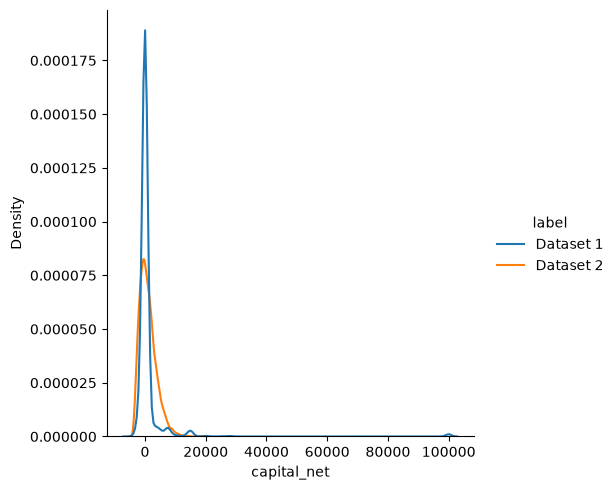

In [46]:
import seaborn as sns
df_reset_copy__ = df_reset_copy_.copy()
synthetic_data_ = synthetic_data.copy()
df_reset_copy__['label'] = 'Dataset 1'
synthetic_data_['label'] = 'Dataset 2'

combined_data = pd.concat([df_reset_copy__, synthetic_data_])

sns.displot(combined_data, x="capital_net", kind="kde", hue='label')

In [47]:
synthetic_data['capital_net'] = round(np.sign(synthetic_data['capital_net_log']) * (np.exp2(abs(synthetic_data['capital_net_log']))+1)).astype(int)

In [48]:
df_reset_copy_ = df_reset_copy_.drop('capital_net_log', axis=1)
synthetic_data = synthetic_data.drop('capital_net_log', axis=1)


In [49]:
df_reset_copy_.to_csv("adult-data-census-complete.csv", index=False)

In [50]:
data = connector.read(
    folder_name='',
    file_names=['adult-data-census-complete.csv'],
    read_csv_parameters={
        'parse_dates': False,
        'encoding':'latin-1'
    }
)

In [51]:
from sdv.metadata import Metadata

metadata = Metadata.detect_from_dataframes(data)

metadata.visualize()
metadata.update_column(
    column_name='education_num',
    sdtype='numerical',
    table_name='adult-data-census-complete'
)

metadata.validate()
metadata.save_to_json('metadata_2.json')

In [52]:
synthetic_data

,age,workclass,fnlwgt,education_num,marital_status,occupation,relationship,race,sex,hours_per_week,native_country,income,capital_net
0,57,Private,116079,11,Married-civ-spouse,Craft-repair,Husband,White,Male,57,United-States,<=50K,-2
1,37,Private,113764,9,Divorced,Adm-clerical,Not-in-family,White,Male,47,United-States,<=50K,10
2,49,Private,164574,16,Married-civ-spouse,Exec-managerial,Husband,Black,Male,37,United-States,>50K,150
3,43,State-gov,258873,9,Never-married,Farming-fishing,Own-child,Black,Female,36,United-States,<=50K,2
4,33,Private,125354,7,Married-civ-spouse,Prof-specialty,Husband,White,Male,50,United-States,<=50K,-6
...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,18,Self-emp-inc,477119,9,Divorced,Sales,Other-relative,Black,Female,25,United-States,<=50K,-8
32557,23,Private,99735,7,Married-civ-spouse,Craft-repair,Wife,White,Female,44,United-States,<=50K,6
32558,17,Private,478180,9,Never-married,Machine-op-inspct,Own-child,White,Female,10,United-States,<=50K,-3
32559,28,Private,148315,11,Married-civ-spouse,Sales,Husband,White,Male,19,United-States,<=50K,12


In [53]:
metadata_dict = metadata.to_dict()
metadata_dict['columns'] = metadata_dict['tables']['adult-data-census-complete']['columns']

In [54]:
from sdmetrics.reports.single_table import DiagnosticReport

report = DiagnosticReport()
report.generate(df_reset_copy_, synthetic_data, metadata_dict)

Generating report ...

(1/2) Evaluating Data Validity: |██████████| 13/13 [00:00<00:00, 328.52it/s]|
Data Validity Score: 99.99%

(2/2) Evaluating Data Structure: |██████████| 1/1 [00:00<00:00, 490.91it/s]|
Data Structure Score: 100.0%

Overall Score (Average): 100.0%



In [55]:
from sdmetrics.reports.single_table import QualityReport

report = QualityReport()
report.generate(df_reset_copy_, synthetic_data, metadata_dict)

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 13/13 [00:00<00:00, 83.98it/s]|
Column Shapes Score: 92.9%

(2/2) Evaluating Column Pair Trends: |██████████| 78/78 [00:00<00:00, 143.39it/s]|
Column Pair Trends Score: 90.24%

Overall Score (Average): 91.57%



In [56]:
score_value_fidelity = round(report.get_score(), ndigits=4)
score_value_fidelity = float(score_value_fidelity * 100)

In [57]:
score_value_fidelity

91.57

In [58]:
report.get_properties()

,Property,Score
0,Column Shapes,0.928964
1,Column Pair Trends,0.902449


In [59]:
column_shapes = report.get_details(property_name='Column Shapes')

In [60]:
column_shapes

,Column,Metric,Score
0,age,KSComplement,0.978901
1,workclass,TVComplement,0.992476
2,fnlwgt,KSComplement,0.954178
3,education_num,KSComplement,0.866497
4,marital_status,TVComplement,0.993981
5,occupation,TVComplement,0.989834
6,relationship,TVComplement,0.996007
7,race,TVComplement,0.999079
8,sex,TVComplement,0.999662
9,hours_per_week,KSComplement,0.765271


In [61]:
!pip install seaborn

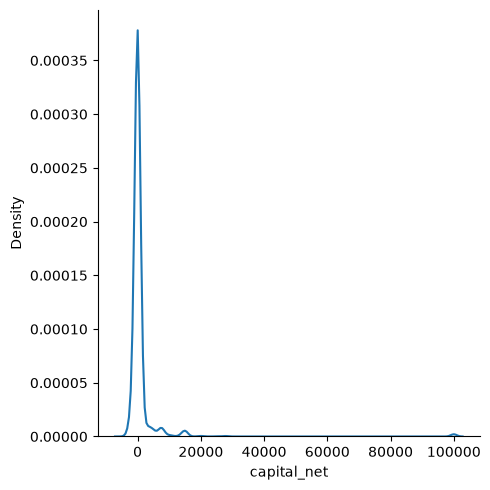

In [62]:
import seaborn as sns

sns.displot(df_reset_copy_, x="capital_net", kind="kde")

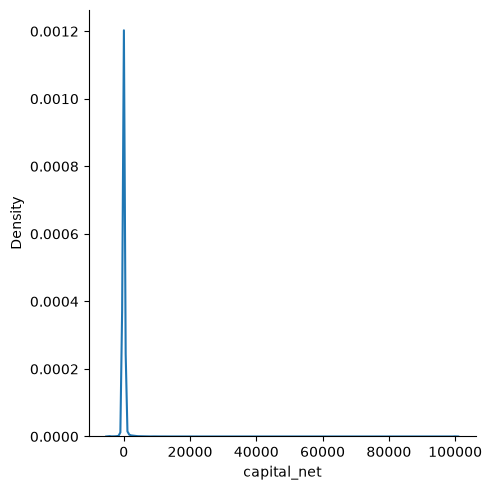

In [63]:
import seaborn as sns

sns.displot(synthetic_data, x="capital_net", kind="kde")

Column shapes, mainly measure differences in distribution between the real and synthetic datasets. For most columns we have values that are okay (>0.75), but for some columns such as 'capital_gain' and 'capital_loss', the values are very low, for example 0.08990 and 0.5210, respectively. It can be seen that for 'capital_gain', in the real data, there is a very high peak at 0, and the high values are very rare, and there is an outlier at 1000000, but for the synthetic data, the distribution is more uniform, steadly declining, when it reaches almost zero between before 120000, and there are fewer values of 0.

As for capital loss, the distribution of zeros is pretty similar across both synthetic and real datasets, but in the real datasets, there is a significant presence of an outlier at around 2000, which is not present in the synthetic dataset. The distribution in the synthetic dataset surprlingly, expect for the outlier, imitates the style of the real dataset, where there is a peak at 0, and a sharp decline.

KSComplement measuring using Kolmogorov-Smirnov the similarity in terms of distribution between the real and synthetic datasets, used for numerical and datetime columns. TVComplement, measuring using Total Variation Distance, the same similarity as KSComplement, but for categorical columns.

We sensed that capital_loss is zero, when capital_gain > 0, and capital_gain is zero, when capital_loss > 0, so we can create a new column called capital_net, which is the difference between capital_gain and capital_loss, and then we can drop the two columns. This helped the dataset create a more better distribution. We obtained the value of 0.50199 for capital_net, which is a better value than the previous values of 0.08990 for capital_gain, but worse than 0.5210 which is for capital_loss respectively.

For capital_net, the distribution of zeros is more pronounced across the real dataset, and the drop in frequence is more abrupt, as compared to the synthetic dataset, which is more linear, and the real dataset has "up and down" fluctuations, while the synthetic dataset is more smooth. In addition, there can be observed an outlier in the real dataset at around 100000, while the synthetic dataset stops at around 20000.

In order to improve these results, we want to smoothen the distribution of capital_net for the synthetic dataset, as it uses gaussian distribution, and after the synthetic dataset is generated, we reverse it back to the original distribution, and 0.542520. But now there are a lot of values in the synthetic data that are gathered around 0 for the capital_net column, while having few outliers.

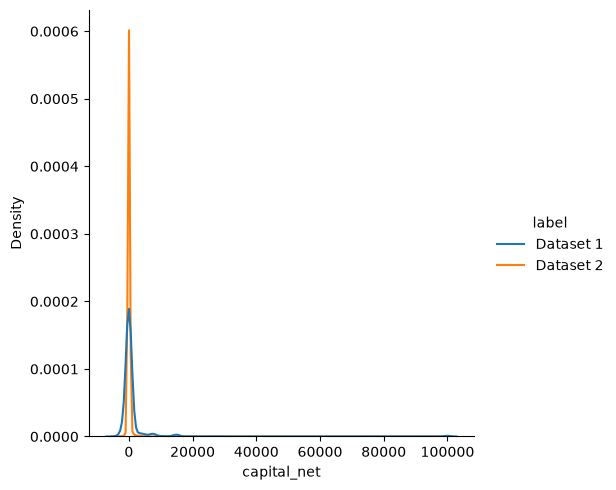

In [64]:
import seaborn as sns
df_reset_copy__ = df_reset_copy_.copy()
synthetic_data_ = synthetic_data.copy()
df_reset_copy__['label'] = 'Dataset 1'
synthetic_data_['label'] = 'Dataset 2'

combined_data = pd.concat([df_reset_copy__, synthetic_data_])

sns.displot(combined_data, x="capital_net", kind="kde", hue='label')

In [65]:

for values in [100, 500, 1000, 2500]:
    x = -values
    y = values
    print("Synthetic data: ", len(synthetic_data[synthetic_data['capital_net']<=y][synthetic_data['capital_net']>=x])/len(synthetic_data), f"values range: [{x}, {y}]")
    print("Real data: ", len(df_reset_copy_[df_reset_copy_['capital_net']<=y][df_reset_copy_['capital_net']>=x])/len(df_reset_copy_), f"values range: [{x}, {y}]")


Synthetic data:  0.8810540216823808 values range: [-100, 100]
Real data:  0.8700592733638401 values range: [-100, 100]
Synthetic data:  0.9643745585209299 values range: [-500, 500]
Real data:  0.8706427935259974 values range: [-500, 500]
Synthetic data:  0.9800681797242099 values range: [-1000, 1000]
Real data:  0.8728540278246982 values range: [-1000, 1000]
Synthetic data:  0.9906636774054851 values range: [-2500, 2500]
Real data:  0.9255551119437364 values range: [-2500, 2500]


In [66]:
synthetic_data_ = synthetic_data_.drop('label', axis=1)

In [67]:
target_column = 'income'

In [68]:
from sklearn.model_selection import train_test_split
x_train_real, x_test_real, y_train_real, y_test_real = train_test_split(df_reset_copy_.copy().loc[:, df_reset_copy_.columns != target_column], df_reset_copy_.copy().loc[:, df_reset_copy_.columns == target_column], test_size=0.2, random_state=42)
x_train_syn, x_test_syn, y_train_syn, y_test_syn = train_test_split(synthetic_data_.copy().loc[:, synthetic_data_.columns != target_column], synthetic_data_.copy().loc[:, synthetic_data_.columns == target_column], test_size=0.2, random_state=42)

In [69]:
encoder = OneHotEncoder(sparse_output=False)
one_hot_encoded_y_train = encoder.fit_transform(y_train_real)
one_hot_df_y_train = pd.DataFrame(one_hot_encoded_y_train,  columns=encoder.get_feature_names_out(y_train_real.columns), index= y_train_real.index)
y_train_real = pd.concat([one_hot_df_y_train], axis=1)


In [70]:
y_test_real_copy = y_test_real.copy()

In [71]:
one_hot_encoded_y_test = encoder.transform(y_test_real)
one_hot_df_y_test = pd.DataFrame(one_hot_encoded_y_test,  columns=encoder.get_feature_names_out(y_test_real.columns), index= y_test_real.index)
y_test_real = pd.concat([one_hot_df_y_test], axis=1)

In [72]:
encoder = OneHotEncoder(sparse_output=False)
one_hot_encoded_y_train_syn = encoder.fit_transform(y_train_syn)
one_hot_df_y_train_syn = pd.DataFrame(one_hot_encoded_y_train_syn,  columns=encoder.get_feature_names_out(y_train_syn.columns), index= y_train_syn.index)
y_train_syn = pd.concat([one_hot_df_y_train_syn], axis=1)

one_hot_encoded_y_test_syn = encoder.transform(y_test_syn)
one_hot_df_y_test_syn = pd.DataFrame(one_hot_encoded_y_test_syn,  columns=encoder.get_feature_names_out(y_test_syn.columns), index= y_test_syn.index)
y_test_syn = pd.concat([one_hot_df_y_test_syn], axis=1)

one_hot_encoded_y_test_copy = encoder.transform(y_test_real_copy)
one_hot_df_y_test_copy = pd.DataFrame(one_hot_encoded_y_test_copy,  columns=encoder.get_feature_names_out(y_test_real_copy.columns), index= y_test_real_copy.index)
y_test_real_copy = pd.concat([one_hot_df_y_test_copy], axis=1)

In [73]:
is_col_OH.remove(target_column)


In [74]:
x_test_real_copy = x_test_real.copy() 

In [75]:
encoder = OneHotEncoder(sparse_output=False)
one_hot_encoded_x_train = encoder.fit_transform(x_train_real[is_col_OH])
one_hot_df_x_train = pd.DataFrame(one_hot_encoded_x_train,  columns=encoder.get_feature_names_out(is_col_OH), index= x_train_real.index)
x_train_real = pd.concat([x_train_real.drop(is_col_OH, axis=1), one_hot_df_x_train], axis=1)

one_hot_encoded_x_test = encoder.transform(x_test_real[is_col_OH])
one_hot_df_x_test = pd.DataFrame(one_hot_encoded_x_test,  columns=encoder.get_feature_names_out(is_col_OH), index= x_test_real.index)
x_test_real = pd.concat([x_test_real.drop(is_col_OH, axis=1), one_hot_df_x_test], axis=1)


In [76]:
encoder = OneHotEncoder(sparse_output=False)
one_hot_encoded_x_train_syn = encoder.fit_transform(x_train_syn[is_col_OH])
one_hot_df_x_train_syn = pd.DataFrame(one_hot_encoded_x_train_syn,  columns=encoder.get_feature_names_out(is_col_OH), index= x_train_syn.index)
x_train_syn = pd.concat([x_train_syn.drop(is_col_OH, axis=1), one_hot_df_x_train_syn], axis=1)

one_hot_encoded_x_test_syn = encoder.transform(x_test_syn[is_col_OH])
one_hot_df_x_test_syn = pd.DataFrame(one_hot_encoded_x_test_syn,  columns=encoder.get_feature_names_out(is_col_OH), index= x_test_syn.index)
x_test_syn = pd.concat([x_test_syn.drop(is_col_OH, axis=1), one_hot_df_x_test_syn], axis=1)

one_hot_encoded_x_test_copy = encoder.transform(x_test_real_copy[is_col_OH])
one_hot_df_x_test_copy = pd.DataFrame(one_hot_encoded_x_test_copy,  columns=encoder.get_feature_names_out(is_col_OH), index= x_test_real_copy.index)
x_test_real_copy = pd.concat([x_test_real_copy.drop(is_col_OH, axis=1), one_hot_df_x_test_copy], axis=1)

In [77]:
from scipy.stats import chi2_contingency
correlated_values_2 = {}
correlated_values_3 = {}

highest_corr_values = []
correlated_columns = set()
value_cosine_similarity = {}
for idx_col_cat in range(len(encoder.get_feature_names_out(is_col_OH))):

    for idx_col_cat_2 in range(idx_col_cat+1, len(encoder.get_feature_names_out(is_col_OH))):
        col_cat = encoder.get_feature_names_out(is_col_OH)[idx_col_cat]
        
        col_cat_2 = encoder.get_feature_names_out(is_col_OH)[idx_col_cat_2]

        
        
        contingency_table = pd.crosstab(x_train_syn[col_cat], x_train_syn[col_cat_2])
        chi2_statistic, p_value, dof, expected = chi2_contingency(contingency_table)
        n = contingency_table.sum().sum()
        phi2 = chi2_statistic / n
        r, k = contingency_table.shape
        if n == 1:
            v = 0
        else: 
            phi2corr = max(0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
            k_corr = k - (k - 1) * (k - 2) / (n - 1)
            r_corr = r - (r - 1) * (r - 2) / (n - 1)
            if k_corr == 1 and r_corr == 1:
                v = 0
            elif k_corr != 1 and r_corr==1:
                v = np.sqrt(phi2corr/(k_corr-1))
            elif r_corr != 1 and k_corr == 1:
                v = np.sqrt(phi2corr/(r_corr-1))
            else:
                v = np.sqrt(phi2corr / min(k_corr - 1, r_corr - 1))
        
        

        if v > 0.5:
            print("v=", v, " col_cat=", col_cat, " col_cat_2=", col_cat_2)
            

        
        if v > 0.6:
            
            if (col_cat, col_cat_2) not in correlated_columns or (col_cat_2, col_cat) not in correlated_columns:
                correlated_columns.add((col_cat, col_cat_2))
            if col_cat in correlated_values_2.keys():
                list_cat = correlated_values_2[col_cat]
                list_cat_2 = correlated_values_3[col_cat]
                list_cat.append((float(v), col_cat_2))
                list_cat_2.append(col_cat_2)
                correlated_values_2[col_cat] = list_cat
                correlated_values_3[col_cat] = list_cat_2

            else:
                correlated_values_2[col_cat] = [(float(v), col_cat_2)]
                correlated_values_3[col_cat] = [col_cat_2]
            
            if col_cat_2 in correlated_values_2.keys():
                list_cat = correlated_values_2[col_cat_2]
                list_cat_2 = correlated_values_3[col_cat_2]
                list_cat.append((float(v), col_cat))
                list_cat_2.append(col_cat)
                correlated_values_2[col_cat_2] = list_cat
                correlated_values_3[col_cat_2] = list_cat_2
            else:
                correlated_values_2[col_cat_2] = [(float(v), col_cat)]
                correlated_values_3[col_cat_2] = [col_cat]
      

v= 0.5187717080042924  col_cat= workclass_Private  col_cat_2= workclass_Self-emp-not-inc
v= 0.641782768678107  col_cat= marital_status_Married-civ-spouse  col_cat_2= marital_status_Never-married
v= 0.8927175487712122  col_cat= marital_status_Married-civ-spouse  col_cat_2= relationship_Husband
v= 0.5366658353777748  col_cat= marital_status_Married-civ-spouse  col_cat_2= relationship_Not-in-family
v= 0.5733800889732079  col_cat= marital_status_Never-married  col_cat_2= relationship_Husband
v= 0.5100934406799141  col_cat= marital_status_Never-married  col_cat_2= relationship_Own-child
v= 0.5848522979168036  col_cat= relationship_Husband  col_cat_2= sex_Female
v= 0.5848522979168036  col_cat= relationship_Husband  col_cat_2= sex_Male
v= 0.7949465052310304  col_cat= race_Black  col_cat_2= race_White
v= 0.9998941485851925  col_cat= sex_Female  col_cat_2= sex_Male


In [78]:
if len(y_train_real.columns) == 2 and target_column not in y_train_real.columns:
    y_train_real = y_train_real.drop(y_train_real.columns[0], axis=1)
    y_test_real = y_test_real.drop(y_test_real.columns[0], axis=1)
    y_test_real_copy = y_test_real_copy.drop(y_test_real_copy.columns[0], axis=1)
    y_train_syn = y_train_syn.drop(y_train_syn.columns[0], axis=1)
    y_test_syn = y_test_syn.drop(y_test_syn.columns[0], axis=1)

We use logistic regression, random forest, SVM, KNN and Decision Tree Classifier to evaluate the performance of the synthetic dataset, and we compare it with a real dataset. 


In [79]:

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import KFold
model_simple = LogisticRegression(
    random_state=42
)
our_columns = list(x_train_syn.columns)


scoring2 = {
    'Accuracy': 'accuracy',
    'Precision': 'precision',
    'ROC': 'roc_auc',
    'AUPRC': 'average_precision',
    'Recall': 'recall'
}

param_grid = {
    'C': [0.1, 1, 10],
    'max_iter': [50, 100, 500, 2500, 10000],
}
x_train_syn_c = x_train_syn.copy()

x_train_syn_c=x_train_syn_c.drop(columns='capital_net', axis=1)
clf = RandomizedSearchCV(model_simple, param_grid, n_iter=15, scoring = scoring2, random_state=0, n_jobs=-1, cv=KFold(n_splits=5, shuffle=True, random_state=42), refit=False)
clf.fit(x_train_syn_c, y_train_syn)


/Users/madalinamarcu/anaconda3/envs/sdv_proiect/lib/python3.11/site-packages/sklearn/utils/validation.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/madalinamarcu/anaconda3/envs/sdv_proiect/lib/python3.11/site-packages/sklearn/utils/validation.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/madalinamarcu/anaconda3/envs/sdv_proiect/lib/python3.11/site-packages/sklearn/utils/validation.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/madalinamarcu/anaconda3/envs/sdv_proiect/lib/python3.11/site-packages/sklearn/utils/validatio

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'C': [0.1, 1, ...], 'max_iter': [50, 100, ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",15
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.","{'AUPRC': 'average_precision', 'Accuracy': 'accuracy', 'Precision': 'precision', 'ROC': 'roc_auc', ...}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",False
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits w

In [80]:
table_element = pd.DataFrame({'C': clf.cv_results_['param_C'], 'max_iter': clf.cv_results_['param_max_iter'],  'accuracy':clf.cv_results_['mean_test_Accuracy'], 'precision': clf.cv_results_['mean_test_Precision'], 'recall':clf.cv_results_['mean_test_Recall'], 'AUPRC':clf.cv_results_['mean_test_AUPRC'],  'roc_auc':clf.cv_results_['mean_test_ROC']})

In [81]:
table_element

,C,max_iter,accuracy,precision,recall,AUPRC,roc_auc
0,0.1,50,0.759559,0.000000,0.000000,0.211981,0.450650
1,0.1,100,0.759021,0.075000,0.003523,0.226296,0.467150
2,0.1,500,0.759904,0.503445,0.042273,0.361754,0.649821
3,0.1,2500,0.760557,0.522597,0.044278,0.371240,0.656983
4,0.1,10000,0.760749,0.531804,0.042223,0.372743,0.657679
5,1.0,50,0.759559,0.000000,0.000000,0.212083,0.450849
6,1.0,100,0.759482,0.095000,0.003188,0.226702,0.466552
7,1.0,500,0.759751,0.507034,0.042252,0.360600,0.648370
8,1.0,2500,0.760519,0.527335,0.047664,0.371849,0.656967
9,1.0,10000,0.760864,0.532907,0.044806,0.372207,0.657140


In [82]:
import polars as pl

from great_tables import GT, from_column, style, loc
from great_tables.data import airquality
table_element = table_element.sort_values(by=['AUPRC'], ascending=False, ignore_index=True)

gt_table_element = GT(table_element)
location_list = []
for idx, elements in enumerate(table_element.columns):
    if "precision" in elements or "accuracy" in elements or "recall" in elements or "AUPRC" in elements or "roc_auc" in elements:
        pos_min, pos_max = (np.argmin(table_element[elements]), np.argmax(table_element[elements]))
        location_list.append(loc.body(columns=elements, rows=[int(pos_min), int(pos_max)]))
        


In [83]:
gt_table_element.tab_style(
    style=style.text(color="black", font="Times New Roman", weight="bold"),
    locations=location_list
)  


C,max_iter,accuracy,precision,recall,AUPRC,roc_auc
0.1,10000,0.760748991576295,0.5318039590157307,0.04222276015859463,0.3727427412982849,0.6576790380715943
1.0,10000,0.7608641547240879,0.5329065475369179,0.04480620926664525,0.3722067017171778,0.657140329222262
10.0,2500,0.7608641915715786,0.5264233673733557,0.04755481936592458,0.3721070624080551,0.6570657893229448
10.0,10000,0.7607873940312224,0.5305061376672586,0.04572662179885295,0.3720297263440433,0.6572378027988437
1.0,2500,0.760518680019706,0.5273351790524466,0.04766430027358627,0.37184947516052735,0.6569666183665207
0.1,2500,0.7605570898441314,0.5225967815378318,0.0442775478992539,0.3712400839703599,0.6569830385456403
10.0,500,0.7604418382623608,0.5146307501768203,0.04706596081373447,0.3628897432728603,0.6496911008397909
0.1,500,0.7599043439138446,0.5034446421342973,0.042273024833601854,0.36175412289054415,0.6498210621971662
1.0,500,0.7597507783111247,0.5070339487514447,0.042251617118540204,0.36059956675506144,0.6483704940708057
1.0,100,0.759481909540147,0.095,0.0031879194630872487,0.22670179131396848,0.46655172794716115


In [84]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score, average_precision_score


model = LogisticRegression(max_iter=10000, n_jobs=-1, C=0.1, random_state=42)
model.fit(x_train_syn, y_train_syn[y_train_syn.columns[0]])
y_pred = model.predict(x_test_real)
print("Accuracy of Logistic Regression model is:", accuracy_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("ROC of Logistic Regression model is:", roc_auc_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("Precision of Logistic Regression model is:", precision_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("Recall of Logistic Regression model is:", recall_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("AUPRC of Logistic Regression model is:", average_precision_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")

/Users/madalinamarcu/anaconda3/envs/sdv_proiect/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


Accuracy of Logistic Regression model is: 77.30692461231384 %
ROC of Logistic Regression model is: 53.48092616554451 %
Precision of Logistic Regression model is: 82.97872340425532 %
Recall of Logistic Regression model is: 7.447485677912158 %
AUPRC of Logistic Regression model is: 28.50441014726499 %


In [85]:
model_name = "LogisticRegression"
hyper_parameters = "max_iter=10000, C=0.1"
type_ = "synthetic"
values_dict = {}
values_dict["model_name"] = []
values_dict["data_type"] = []
values_dict["hyper_parameters"] = []
values_dict["accuracy"] = []
values_dict["precision"] = []
values_dict["recall"] = []
values_dict["roc_auc"] = []
values_dict["auprc"] = []

values_dict["data_type"].append(type_)
values_dict["model_name"].append(model_name)
values_dict["hyper_parameters"].append(hyper_parameters)
values_dict["accuracy"].append(accuracy_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["precision"].append(precision_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["recall"].append(recall_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["roc_auc"].append(roc_auc_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["auprc"].append(average_precision_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))

In [86]:

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import KFold
model_simple = LogisticRegression(
    random_state=42
)
our_columns = list(x_train_syn.columns)


scoring2 = {
    'Accuracy': 'accuracy',
    'Precision': 'precision',
    'ROC': 'roc_auc',
    'AUPRC': 'average_precision',
    'Recall': 'recall'
}

param_grid = {
    'C': [0.1, 1, 10],
    'max_iter': [50, 100, 500, 2500, 10000],
}

clf = RandomizedSearchCV(model_simple, param_grid, n_iter=15, scoring = scoring2, random_state=0, n_jobs=-1, cv=KFold(n_splits=5, shuffle=True, random_state=42), refit=False)
clf.fit(x_train_real, y_train_real)


/Users/madalinamarcu/anaconda3/envs/sdv_proiect/lib/python3.11/site-packages/sklearn/utils/validation.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/madalinamarcu/anaconda3/envs/sdv_proiect/lib/python3.11/site-packages/sklearn/utils/validation.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/madalinamarcu/anaconda3/envs/sdv_proiect/lib/python3.11/site-packages/sklearn/utils/validation.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/madalinamarcu/anaconda3/envs/sdv_proiect/lib/python3.11/site-packages/sklearn/utils/validatio

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'C': [0.1, 1, ...], 'max_iter': [50, 100, ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",15
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.","{'AUPRC': 'average_precision', 'Accuracy': 'accuracy', 'Precision': 'precision', 'ROC': 'roc_auc', ...}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",False
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits w

In [87]:
table_element = pd.DataFrame({'C': clf.cv_results_['param_C'], 'max_iter': clf.cv_results_['param_max_iter'],  'accuracy':clf.cv_results_['mean_test_Accuracy'], 'precision': clf.cv_results_['mean_test_Precision'], 'recall':clf.cv_results_['mean_test_Recall'], 'AUPRC':clf.cv_results_['mean_test_AUPRC'], 'roc_auc':clf.cv_results_['mean_test_ROC']})

In [88]:
import polars as pl

from great_tables import GT, from_column, style, loc
from great_tables.data import airquality
table_element = table_element.sort_values(by=['AUPRC'], ascending=False, ignore_index=True)

gt_table_element = GT(table_element)
location_list = []
for idx, elements in enumerate(table_element.columns):
    if "precision" in elements or "accuracy" in elements or "AUPRC" in elements  or "recall" in elements or "roc_auc" in elements:
        pos_min, pos_max = (np.argmin(table_element[elements]), np.argmax(table_element[elements]))
        location_list.append(loc.body(columns=elements, rows=[int(pos_min), int(pos_max)]))
        


In [89]:
gt_table_element.tab_style(
    style=style.text(color="black", font="Times New Roman", weight="bold"),
    locations=location_list
)  


C,max_iter,accuracy,precision,recall,AUPRC,roc_auc
10.0,10000,0.8454393676381017,0.7181359128010248,0.5895442658730754,0.7430895941201674,0.8978905968135749
0.1,10000,0.8444795420888621,0.7202089477623581,0.5789967652426986,0.7429976924273909,0.8977674788749794
1.0,10000,0.844863404509175,0.7188774105364628,0.5836523577510346,0.7415581727376395,0.8970679705758859
0.1,2500,0.8425601931398077,0.7168105918459912,0.5721096998759069,0.7352343749954267,0.8926631236314853
1.0,2500,0.8402567680549942,0.7096471795802278,0.5687281946651316,0.731944154863036,0.8912761396165069
10.0,2500,0.8377229282406169,0.7045954274716063,0.5611423823158669,0.7283301205100332,0.8889896086040684
1.0,500,0.834997311975545,0.7033233910963428,0.5428336027044844,0.7145479886597356,0.8817392450309247
10.0,500,0.8350740505599159,0.7041246444828616,0.5428869465800522,0.7105085186002484,0.879807114598111
0.1,500,0.830812564552198,0.7008782725592061,0.5198354037920263,0.702357080726779,0.8748463070469896
10.0,100,0.7813656122265871,0.5767890967205115,0.34029524391353383,0.5832912667823735,0.8091463929930776


In [90]:
from sklearn.linear_model import LogisticRegression


model = LogisticRegression(max_iter=10000, n_jobs=-1, C=10.0, random_state=42)
model.fit(x_train_real, y_train_real[y_train_real.columns[0]])
y_pred = model.predict(x_test_real)
print("Accuracy of Logistic Regression model is:", accuracy_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("ROC of Logistic Regression model is:", roc_auc_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("Precision of Logistic Regression model is:", precision_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("Recall of Logistic Regression model is:", recall_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("AUPRC of Logistic Regression model is:", average_precision_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")


/Users/madalinamarcu/anaconda3/envs/sdv_proiect/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


Accuracy of Logistic Regression model is: 85.06064793489944 %
ROC of Logistic Regression model is: 76.34856506062302 %
Precision of Logistic Regression model is: 73.5062893081761 %
Recall of Logistic Regression model is: 59.516231699554424 %
AUPRC of Logistic Regression model is: 53.51325867258589 %


In [91]:
model_name = "LogisticRegression"
hyper_parameters = "max_iter=10000, C=10.0"
type_ = "real"

values_dict["model_name"].append(model_name)
values_dict["data_type"].append(type_)
values_dict["hyper_parameters"].append(hyper_parameters)
values_dict["accuracy"].append(accuracy_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["precision"].append(precision_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["recall"].append(recall_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["roc_auc"].append(roc_auc_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["auprc"].append(average_precision_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))

In [92]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier()

In [93]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, GradientBoostingClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import KFold
model_simple = RandomForestClassifier(
    random_state=42
)
our_columns = list(x_train_syn.columns)


scoring2 = {
    'Accuracy': 'accuracy',
    'Precision': 'precision',
    'ROC': 'roc_auc',
    'AUPRC': 'average_precision',
    'Recall': 'recall'
}

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 50, 100, None],
    'max_samples': [0.5, 0.8, 0.9]
}

clf = RandomizedSearchCV(model_simple, param_grid, n_iter=45, scoring = scoring2, random_state=0, n_jobs=-1, cv=KFold(n_splits=5, shuffle=True, random_state=42), refit=False)
clf.fit(x_train_syn, y_train_syn)


/Users/madalinamarcu/anaconda3/envs/sdv_proiect/lib/python3.11/site-packages/sklearn/base.py:1403: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/Users/madalinamarcu/anaconda3/envs/sdv_proiect/lib/python3.11/site-packages/sklearn/base.py:1403: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/Users/madalinamarcu/anaconda3/envs/sdv_proiect/lib/python3.11/site-packages/sklearn/base.py:1403: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/Users/madalinamarcu/anaconda3/envs/sdv_proiect/lib/python3.11/site-packages/sklearn/base.py:1

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': [5, 10, ...], 'max_samples': [0.5, 0.8, ...], 'n_estimators': [50, 100, ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",45
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.","{'AUPRC': 'average_precision', 'Accuracy': 'accuracy', 'Precision': 'precision', 'ROC': 'roc_auc', ...}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",False
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are insta

In [94]:
table_element = pd.DataFrame({'param_max_depth': clf.cv_results_['param_max_depth'], 'param_max_samples':clf.cv_results_['param_max_samples'], 'param_n_estimators':clf.cv_results_['param_n_estimators'], 'accuracy':clf.cv_results_['mean_test_Accuracy'], 'precision': clf.cv_results_['mean_test_Precision'], 'recall':clf.cv_results_['mean_test_Recall'], 'AUPRC':clf.cv_results_['mean_test_AUPRC'], 'roc_auc':clf.cv_results_['mean_test_ROC']})

In [95]:
table_element

,param_max_depth,param_max_samples,param_n_estimators,accuracy,precision,recall,AUPRC,roc_auc
0,5,0.5,50,0.759559,0.000000,0.000000,0.365834,0.654467
1,5,0.5,100,0.759559,0.000000,0.000000,0.367878,0.654626
2,5,0.5,200,0.759559,0.000000,0.000000,0.367752,0.654893
3,5,0.8,50,0.759559,0.000000,0.000000,0.365104,0.653908
4,5,0.8,100,0.759559,0.000000,0.000000,0.366003,0.654814
5,5,0.8,200,0.759559,0.000000,0.000000,0.366624,0.654761
6,5,0.9,50,0.759559,0.000000,0.000000,0.364961,0.654101
7,5,0.9,100,0.759559,0.000000,0.000000,0.364829,0.653890
8,5,0.9,200,0.759559,0.000000,0.000000,0.365899,0.653939
9,10,0.5,50,0.760250,0.786667,0.004142,0.370349,0.655178


In [96]:
!pip install polars
!pip install great_tables

In [97]:
import polars as pl

from great_tables import GT, from_column, style, loc
from great_tables.data import airquality
table_element = table_element.sort_values(by=['AUPRC'], ascending=False)

gt_table_element = GT(table_element)
location_list = []
for idx, elements in enumerate(table_element.columns):
    if "param" not in elements:
        pos_min, pos_max = (np.argmin(table_element[elements]), np.argmax(table_element[elements]))
        location_list.append(loc.body(columns=elements, rows=[int(pos_min), int(pos_max)]))
        


In [98]:
gt_table_element.tab_style(
    style=style.text(color="black", font="Times New Roman", weight="bold"),
    locations=location_list
)  


param_max_depth,param_max_samples,param_n_estimators,accuracy,precision,recall,AUPRC,roc_auc
10,0.5,100,0.7598658088079505,0.8933333333333333,0.0015971439071016565,0.37209513223253665,0.6560892467767201
10,0.5,200,0.7598658088079505,0.8666666666666666,0.001606777267152412,0.3717557656175995,0.6577659341149388
10,0.8,200,0.7599041965238814,0.6333333333333333,0.001957264309823454,0.37150508806625543,0.6575708868726461
10,0.9,200,0.7597506309211615,0.7166666666666666,0.0016148664461248928,0.3711514780875181,0.6582834132353417
10,0.5,50,0.7602496933367576,0.7866666666666666,0.004142329557720291,0.37034852756901976,0.6551780568075068
10,0.9,100,0.7597122432052306,0.6033333333333333,0.0017650051152536777,0.36859423645760686,0.6562563359026049
5,0.5,100,0.7595586849720088,0.0,0.0,0.3678784402940607,0.6546255663272514
5,0.5,200,0.7595586849720088,0.0,0.0,0.36775221051787266,0.6548927174343678
10,0.8,100,0.7597890186370924,0.5433333333333333,0.001954664766425606,0.36763776156408867,0.6560431471538359
5,0.8,200,0.7595586849720088,0.0,0.0,0.3666236840016106,0.6547613969347321


In [99]:
model = RandomForestClassifier(max_depth=10, max_samples=0.9, n_estimators=200, n_jobs=-1, random_state=42)
model.fit(x_train_syn, y_train_syn[y_train_syn.columns[0]])
y_pred = model.predict(x_test_real)
print("Accuracy of RandomForestClassifier model is:", accuracy_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("ROC of RandomForestClassifier model is:", roc_auc_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("Precision of RandomForestClassifier model is:", precision_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("Recall of RandomForestClassifier model is:", recall_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("AUPRC of RandomForestClassifier model is:", average_precision_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")

print(" ")

model = RandomForestClassifier(max_depth=10, max_samples=0.8, n_estimators=50, n_jobs=-1, random_state=42)
model.fit(x_train_syn, y_train_syn[y_train_syn.columns[0]])
y_pred_2 = model.predict(x_test_real)
print("Accuracy of RandomForestClassifier model is:", accuracy_score(y_test_real[y_test_real.columns[0]], y_pred_2)*100, "%")
print("ROC of RandomForestClassifier model is:", roc_auc_score(y_test_real[y_test_real.columns[0]], y_pred_2)*100, "%")
print("Precision of RandomForestClassifier model is:", precision_score(y_test_real[y_test_real.columns[0]], y_pred_2)*100, "%")
print("Recall of RandomForestClassifier model is:", recall_score(y_test_real[y_test_real.columns[0]], y_pred_2)*100, "%")
print("AUPRC of RandomForestClassifier model is:", average_precision_score(y_test_real[y_test_real.columns[0]], y_pred_2)*100, "%")


Accuracy of RandomForestClassifier model is: 75.87901120835252 %
ROC of RandomForestClassifier model is: 50.0 %
Precision of RandomForestClassifier model is: 0.0 %
Recall of RandomForestClassifier model is: 0.0 %
AUPRC of RandomForestClassifier model is: 24.120988791647473 %
 
Accuracy of RandomForestClassifier model is: 75.9557807461999 %
ROC of RandomForestClassifier model is: 50.1591343093571 %
Precision of RandomForestClassifier model is: 100.0 %
Recall of RandomForestClassifier model is: 0.31826861871419476 %
AUPRC of RandomForestClassifier model is: 24.362487872514286 %


/Users/madalinamarcu/anaconda3/envs/sdv_proiect/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [100]:
model_name = "RandomForestClassifier"
hyper_parameters = "max_depth=10, max_samples=0.9, n_estimators=200"
type_ = "synthetic"

values_dict["model_name"].append(model_name)
values_dict["data_type"].append(type_)
values_dict["hyper_parameters"].append(hyper_parameters)
values_dict["accuracy"].append(accuracy_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["precision"].append(precision_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["recall"].append(recall_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["roc_auc"].append(roc_auc_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["auprc"].append(average_precision_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))


model_name = "RandomForestClassifier"
hyper_parameters = "max_depth=50, max_samples=0.8, n_estimators=50"
type_ = "synthetic"

values_dict["model_name"].append(model_name)
values_dict["data_type"].append(type_)
values_dict["hyper_parameters"].append(hyper_parameters)
values_dict["accuracy"].append(accuracy_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred_2))
values_dict["precision"].append(precision_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred_2))
values_dict["recall"].append(recall_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred_2))
values_dict["roc_auc"].append(roc_auc_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred_2))
values_dict["auprc"].append(average_precision_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred_2))

/Users/madalinamarcu/anaconda3/envs/sdv_proiect/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [101]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, GradientBoostingClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import KFold
model_simple = RandomForestClassifier(
    random_state=42
)
our_columns = list(x_train_real.columns)


scoring2 = {
    'Accuracy': 'accuracy',
    'Precision': 'precision',
    'ROC': 'roc_auc',
    'AUPRC': 'average_precision',
    'Recall': 'recall'
}

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 50, 100, None],
    'max_samples': [0.5, 0.8, 0.9]
}

clf = RandomizedSearchCV(model_simple, param_grid, n_iter=45, scoring = scoring2, random_state=0, n_jobs=-1, cv=KFold(n_splits=5, shuffle=True, random_state=42), refit=False)
clf.fit(x_train_real, y_train_real)


/Users/madalinamarcu/anaconda3/envs/sdv_proiect/lib/python3.11/site-packages/sklearn/base.py:1403: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/Users/madalinamarcu/anaconda3/envs/sdv_proiect/lib/python3.11/site-packages/sklearn/base.py:1403: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/Users/madalinamarcu/anaconda3/envs/sdv_proiect/lib/python3.11/site-packages/sklearn/base.py:1403: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/Users/madalinamarcu/anaconda3/envs/sdv_proiect/lib/python3.11/site-packages/sklearn/base.py:1

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': [5, 10, ...], 'max_samples': [0.5, 0.8, ...], 'n_estimators': [50, 100, ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",45
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.","{'AUPRC': 'average_precision', 'Accuracy': 'accuracy', 'Precision': 'precision', 'ROC': 'roc_auc', ...}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",False
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are insta

In [102]:
table_element_real = pd.DataFrame({'param_max_depth': clf.cv_results_['param_max_depth'], 'param_max_samples':clf.cv_results_['param_max_samples'], 'param_n_estimators':clf.cv_results_['param_n_estimators'], 'accuracy':clf.cv_results_['mean_test_Accuracy'], 'precision': clf.cv_results_['mean_test_Precision'], 'recall':clf.cv_results_['mean_test_Recall'], 'AUPRC':clf.cv_results_['mean_test_AUPRC'], 'roc_auc':clf.cv_results_['mean_test_ROC']})

In [103]:
table_element_real

,param_max_depth,param_max_samples,param_n_estimators,accuracy,precision,recall,AUPRC,roc_auc
0,5,0.5,50,0.843212,0.844022,0.429261,0.762212,0.898088
1,5,0.5,100,0.841638,0.832509,0.430213,0.761764,0.898824
2,5,0.5,200,0.841946,0.826927,0.435077,0.761096,0.898623
3,5,0.8,50,0.841139,0.842109,0.418316,0.762437,0.897772
4,5,0.8,100,0.840717,0.831096,0.425326,0.760886,0.898494
5,5,0.8,200,0.841255,0.826428,0.431156,0.760212,0.898472
6,5,0.9,50,0.842137,0.840802,0.424626,0.761814,0.897536
7,5,0.9,100,0.841063,0.833496,0.425296,0.761140,0.898618
8,5,0.9,200,0.840909,0.824512,0.430730,0.759574,0.898208
9,10,0.5,50,0.857340,0.801705,0.541192,0.787678,0.910165


In [104]:
import polars as pl

from great_tables import GT, from_column, style, loc
from great_tables.data import airquality
table_element_real = table_element_real.sort_values(by=['AUPRC'], ascending=False, ignore_index=True)

gt_table_element = GT(table_element_real)
location_list = []
for idx, elements in enumerate(table_element_real.columns):
    if "param" not in elements:
        pos_min, pos_max = (np.argmin(table_element_real[elements]), np.argmax(table_element_real[elements]))
        location_list.append(loc.body(columns=elements, rows=[int(pos_min), int(pos_max)]))
        


In [105]:
gt_table_element.tab_style(
    style=style.text(color="black", font="Times New Roman", weight="bold"),
    locations=location_list
)  


param_max_depth,param_max_samples,param_n_estimators,accuracy,precision,recall,AUPRC,roc_auc
10,0.8,100,0.8564190503001413,0.7966361991948333,0.5422416045090805,0.7902811532884172,0.911545564450547
10,0.8,200,0.8566109667713013,0.7965900753071031,0.5433432651869932,0.7902582478609241,0.9115772029809559
10,0.5,200,0.8566878011591484,0.7960409387578748,0.5438771368981713,0.7896277406040424,0.9114835301009165
10,0.8,50,0.8571484684893156,0.8027110540777045,0.5391038578214442,0.7895455971754851,0.9108387696077912
10,0.9,100,0.8575322424756502,0.8010391909409368,0.5435190961843008,0.7890573933325047,0.9109600535441418
10,0.5,100,0.8575323824961154,0.7967909145922611,0.5477279793753603,0.7887665833373209,0.9109878189170336
10,0.9,200,0.8569564488451812,0.7994617884968982,0.5419340802019575,0.7887047203356624,0.9111561338864431
10,0.9,50,0.8572251039007123,0.8000875160972495,0.5427400558010553,0.7881449162384823,0.9102108109614818
10,0.5,50,0.8573404144384682,0.8017045623704655,0.5411922434843237,0.7876784222727622,0.9101646174796441
50,0.5,200,0.8582232803183919,0.7455022281011143,0.6239783228325346,0.7793313356157422,0.9089793494368159


In [106]:
model = RandomForestClassifier(max_depth=100, max_samples=0.5, n_estimators=200, n_jobs=-1, random_state=42)
model.fit(x_train_real, y_train_real[y_train_real.columns[0]])
y_pred = model.predict(x_test_real)
print("Accuracy of RandomForestClassifier model is:", accuracy_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("ROC of RandomForestClassifier model is:", roc_auc_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("Precision of RandomForestClassifier model is:", precision_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("Recall of RandomForestClassifier model is:", recall_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("AUPRC of RandomForestClassifier model is:", average_precision_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")


print(" ")
model = RandomForestClassifier(max_depth=10, max_samples=0.8, n_estimators=100, n_jobs=-1, random_state=42)
model.fit(x_train_real, y_train_real[y_train_real.columns[0]])
y_pred_2 = model.predict(x_test_real)
print("Accuracy of RandomForestClassifier model is:", accuracy_score(y_test_real[y_test_real.columns[0]], y_pred_2)*100, "%")
print("ROC of RandomForestClassifier model is:", roc_auc_score(y_test_real[y_test_real.columns[0]], y_pred_2)*100, "%")
print("Precision of RandomForestClassifier model is:", precision_score(y_test_real[y_test_real.columns[0]], y_pred_2)*100, "%")
print("Recall of RandomForestClassifier model is:", recall_score(y_test_real[y_test_real.columns[0]], y_pred_2)*100, "%")
print("AUPRC of RandomForestClassifier model is:", average_precision_score(y_test_real[y_test_real.columns[0]], y_pred_2)*100, "%")


Accuracy of RandomForestClassifier model is: 86.65745432212498 %
ROC of RandomForestClassifier model is: 78.68163117368347 %
Precision of RandomForestClassifier model is: 77.29393468118197 %
Recall of RandomForestClassifier model is: 63.271801400381925 %
AUPRC of RandomForestClassifier model is: 57.76446951360627 %
 
Accuracy of RandomForestClassifier model is: 86.0586519269154 %
ROC of RandomForestClassifier model is: 75.85559002571136 %
Precision of RandomForestClassifier model is: 80.10899182561307 %
Recall of RandomForestClassifier model is: 56.142584341183955 %
AUPRC of RandomForestClassifier model is: 55.55410061593624 %


In [107]:
model_name = "RandomForestClassifier"
hyper_parameters = "max_depth=100, max_samples=0.5, n_estimators=200"
type_ = "real"

values_dict["model_name"].append(model_name)
values_dict["data_type"].append(type_)
values_dict["hyper_parameters"].append(hyper_parameters)
values_dict["accuracy"].append(accuracy_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["precision"].append(precision_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["recall"].append(recall_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["roc_auc"].append(roc_auc_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict['auprc'].append(average_precision_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))


model_name = "RandomForestClassifier"
hyper_parameters = "max_depth=10, max_samples=0.8, n_estimators=100"
type_ = "real"

values_dict["model_name"].append(model_name)
values_dict["data_type"].append(type_)
values_dict["hyper_parameters"].append(hyper_parameters)
values_dict["accuracy"].append(accuracy_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred_2))
values_dict["precision"].append(precision_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred_2))
values_dict["recall"].append(recall_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred_2))
values_dict["roc_auc"].append(roc_auc_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred_2))
values_dict['auprc'].append(average_precision_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred_2))


In [108]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn import svm
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import KFold
model_simple = svm.SVC(
    random_state=42
)
our_columns = list(x_train_syn.columns)


scoring2 = {
    'Accuracy': 'accuracy',
    'Precision': 'precision',
    'ROC': 'roc_auc',
    'Recall': 'recall',
    'AUPRC': 'average_precision'
}

param_grid = {
    'C': [0.1, 1, 10],
    'max_iter': [100, 500, 1500, 5000, 10000],
    'decision_function_shape': ['ovo', 'ovr']
}

clf = RandomizedSearchCV(model_simple, param_grid, n_iter=30, scoring = scoring2, random_state=0, n_jobs=-1, cv=KFold(n_splits=5, shuffle=True, random_state=42), refit=False)
clf.fit(x_train_syn, y_train_syn)


/Users/madalinamarcu/anaconda3/envs/sdv_proiect/lib/python3.11/site-packages/sklearn/utils/validation.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/madalinamarcu/anaconda3/envs/sdv_proiect/lib/python3.11/site-packages/sklearn/utils/validation.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/madalinamarcu/anaconda3/envs/sdv_proiect/lib/python3.11/site-packages/sklearn/utils/validation.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/madalinamarcu/anaconda3/envs/sdv_proiect/lib/python3.11/site-packages/sklearn/utils/validatio

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SVC(random_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'C': [0.1, 1, ...], 'decision_function_shape': ['ovo', 'ovr'], 'max_iter': [100, 500, ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",30
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.","{'AUPRC': 'average_precision', 'Accuracy': 'accuracy', 'Precision': 'precision', 'ROC': 'roc_auc', ...}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",False
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwi

In [109]:
table_element_real = pd.DataFrame({'C': clf.cv_results_['param_C'], 'max_iter':clf.cv_results_['param_max_iter'], 'decision_function_shape':clf.cv_results_['param_decision_function_shape'], 'accuracy':clf.cv_results_['mean_test_Accuracy'], 'precision': clf.cv_results_['mean_test_Precision'], 'recall':clf.cv_results_['mean_test_Recall'], 'AUPRC':clf.cv_results_['mean_test_AUPRC'], 'roc_auc':clf.cv_results_['mean_test_ROC']})

In [110]:
table_element_real

,C,max_iter,decision_function_shape,accuracy,precision,recall,AUPRC,roc_auc
0,0.1,100,ovo,0.349125,0.240299,0.789735,0.244971,0.506113
1,0.1,500,ovo,0.349586,0.241838,0.798388,0.250151,0.511022
2,0.1,1500,ovo,0.345094,0.240673,0.798882,0.243178,0.500269
3,0.1,5000,ovo,0.623321,0.139338,0.264957,0.243773,0.503202
4,0.1,10000,ovo,0.759559,0.000000,0.000000,0.247678,0.503504
5,0.1,100,ovr,0.349125,0.240299,0.789735,0.244971,0.506113
6,0.1,500,ovr,0.349586,0.241838,0.798388,0.250151,0.511022
7,0.1,1500,ovr,0.345094,0.240673,0.798882,0.243178,0.500269
8,0.1,5000,ovr,0.623321,0.139338,0.264957,0.243773,0.503202
9,0.1,10000,ovr,0.759559,0.000000,0.000000,0.247678,0.503504


In [111]:
import polars as pl

from great_tables import GT, from_column, style, loc
from great_tables.data import airquality
table_element_real = table_element_real.sort_values(by=['AUPRC'], ascending=False, ignore_index=True)

gt_table_element = GT(table_element_real)
location_list = []
for idx, elements in enumerate(table_element_real.columns):
    if "accuracy" in elements or "precision" in elements or "recall" in elements or "AUPRC" in elements or "roc_auc" in elements:
        pos_min, pos_max = (np.argmin(table_element_real[elements]), np.argmax(table_element_real[elements]))
        location_list.append(loc.body(columns=elements, rows=[int(pos_min), int(pos_max)]))
        


In [112]:
gt_table_element.tab_style(
    style=style.text(color="black", font="Times New Roman", weight="bold"),
    locations=location_list
)  


C,max_iter,decision_function_shape,accuracy,precision,recall,AUPRC,roc_auc
1.0,10000,ovo,0.7595586849720088,0.0,0.0,0.25162239267724773,0.5084938931379555
1.0,10000,ovr,0.7595586849720088,0.0,0.0,0.25162239267724773,0.5084938931379555
0.1,500,ovr,0.3495859115829719,0.2418375402377607,0.7983880659836202,0.25015128612446486,0.5110223777984318
0.1,500,ovo,0.3495859115829719,0.2418375402377607,0.7983880659836202,0.25015128612446486,0.5110223777984318
10.0,500,ovr,0.3695482976643481,0.24090139950353437,0.7545695408450799,0.24897517307471842,0.508685983126181
10.0,500,ovo,0.3695482976643481,0.24090139950353437,0.7545695408450799,0.24897517307471842,0.508685983126181
1.0,500,ovo,0.3695482976643481,0.24090139950353437,0.7545695408450799,0.24897517307471842,0.508685983126181
1.0,500,ovr,0.3695482976643481,0.24090139950353437,0.7545695408450799,0.24897517307471842,0.508685983126181
10.0,10000,ovr,0.7595586849720088,0.0,0.0,0.24893618084680505,0.5069288359585601
10.0,10000,ovo,0.7595586849720088,0.0,0.0,0.24893618084680505,0.5069288359585601


In [113]:
from sklearn import svm

model_simple = svm.SVC(
    random_state=42, C=1.0, max_iter=10000, decision_function_shape="ovo"
)
model_simple.fit(x_train_syn, y_train_syn[y_train_syn.columns[0]])
y_pred = model_simple.predict(x_test_real)
print("Accuracy of Logistic Regression model is:", accuracy_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("ROC of Logistic Regression model is:", roc_auc_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("Precision of Logistic Regression model is:", precision_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("Recall of Logistic Regression model is:", recall_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("AUPRC of Logistic Regression model is:", average_precision_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")

print(" ")
model_simple = svm.SVC(
    random_state=42, C=10.0, max_iter=1500, decision_function_shape="ovo"
)
model_simple.fit(x_train_syn, y_train_syn[y_train_syn.columns[0]])
y_pred_2 = model_simple.predict(x_test_real)
print("Accuracy of svm.SVC model is:", accuracy_score(y_test_real[y_test_real.columns[0]], y_pred_2)*100, "%")
print("ROC of svm.SVC model is:", roc_auc_score(y_test_real[y_test_real.columns[0]], y_pred_2)*100, "%")
print("Precision of svm.SVC model is:", precision_score(y_test_real[y_test_real.columns[0]], y_pred_2)*100, "%")
print("Recall of svm.SVC model is:", recall_score(y_test_real[y_test_real.columns[0]], y_pred_2)*100, "%")
print("AUPRC of svm.SVC model is:", average_precision_score(y_test_real[y_test_real.columns[0]], y_pred_2)*100, "%")


print(" ")
model_simple = svm.SVC(
    random_state=42, C=100.0, max_iter=6330, decision_function_shape="ovr"
)
model_simple.fit(x_train_syn, y_train_syn[y_train_syn.columns[0]])
y_pred_3 = model_simple.predict(x_test_real)
print("Accuracy of svm.SVC model is:", accuracy_score(y_test_real[y_test_real.columns[0]], y_pred_3)*100, "%")
print("ROC of svm.SVC model is:", roc_auc_score(y_test_real[y_test_real.columns[0]], y_pred_3)*100, "%")
print("Precision of svm.SVC model is:", precision_score(y_test_real[y_test_real.columns[0]], y_pred_3)*100, "%")
print("Recall of svm.SVC model is:", recall_score(y_test_real[y_test_real.columns[0]], y_pred_3)*100, "%")
print("AUPRC of svm.SVC model is:", average_precision_score(y_test_real[y_test_real.columns[0]], y_pred_3)*100, "%")


Accuracy of Logistic Regression model is: 75.87901120835252 %
ROC of Logistic Regression model is: 50.0 %
Precision of Logistic Regression model is: 0.0 %
Recall of Logistic Regression model is: 0.0 %
AUPRC of Logistic Regression model is: 24.120988791647473 %
 


/Users/madalinamarcu/anaconda3/envs/sdv_proiect/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/madalinamarcu/anaconda3/envs/sdv_proiect/lib/python3.11/site-packages/sklearn/svm/_base.py:340: ConvergenceWarning: Solver terminated early (max_iter=1500).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


Accuracy of svm.SVC model is: 35.40611085521265 %
ROC of svm.SVC model is: 51.09708648328246 %
Precision of svm.SVC model is: 24.624566807855217 %
Recall of svm.SVC model is: 81.41311266709103 %
AUPRC of svm.SVC model is: 24.530967329349384 %
 


/Users/madalinamarcu/anaconda3/envs/sdv_proiect/lib/python3.11/site-packages/sklearn/svm/_base.py:340: ConvergenceWarning: Solver terminated early (max_iter=6330).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


Accuracy of svm.SVC model is: 57.08582834331337 %
ROC of svm.SVC model is: 47.059982364492406 %
Precision of svm.SVC model is: 20.773638968481375 %
Recall of svm.SVC model is: 27.689369828134947 %
AUPRC of svm.SVC model is: 23.194128719669592 %


In [114]:
model_name = "svm.SVC"
hyper_parameters = "C=1.0, max_iter=10000, decision_function_shape=ovr"
type_ = "synthetic"

values_dict["model_name"].append(model_name)
values_dict["data_type"].append(type_)
values_dict["hyper_parameters"].append(hyper_parameters)
values_dict["accuracy"].append(accuracy_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["precision"].append(precision_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["recall"].append(recall_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["roc_auc"].append(roc_auc_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["auprc"].append(average_precision_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))

model_name = "svm.SVC"
hyper_parameters = "C=10.0, max_iter=1500, decision_function_shape=ovo"
type_ = "synthetic"

values_dict["model_name"].append(model_name)
values_dict["data_type"].append(type_)
values_dict["hyper_parameters"].append(hyper_parameters)
values_dict["accuracy"].append(accuracy_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred_2))
values_dict["precision"].append(precision_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred_2))
values_dict["recall"].append(recall_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred_2))
values_dict["roc_auc"].append(roc_auc_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred_2))
values_dict["auprc"].append(average_precision_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred_2))


model_name = "svm.SVC"
hyper_parameters = "C=100.0, max_iter=6330, decision_function_shape=ovr"
type_ = "synthetic"

values_dict["model_name"].append(model_name)
values_dict["data_type"].append(type_)
values_dict["hyper_parameters"].append(hyper_parameters)
values_dict["accuracy"].append(accuracy_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred_3))
values_dict["precision"].append(precision_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred_3))
values_dict["recall"].append(recall_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred_3))
values_dict["roc_auc"].append(roc_auc_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred_3))
values_dict["auprc"].append(average_precision_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred_3))


/Users/madalinamarcu/anaconda3/envs/sdv_proiect/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [115]:
import pandas as pd
from sklearn import svm
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import KFold
model_simple = svm.SVC(
    random_state=42
)
our_columns = list(x_train_real.columns)


scoring2 = {
    'Accuracy': 'accuracy',
    'Precision': 'precision',
    'ROC': 'roc_auc',
    'AUPRC': 'average_precision',
    'Recall': 'recall'
}

param_grid = {
    'C': [0.1, 1, 10],
    'max_iter': [100, 500, 1500, 5000, 10000],
    'decision_function_shape': ['ovo', 'ovr']
}

clf = RandomizedSearchCV(model_simple, param_grid, n_iter=30, scoring = scoring2, random_state=0, n_jobs=-1, cv=KFold(n_splits=5, shuffle=True, random_state=42), refit=False)
clf.fit(x_train_real, y_train_real)


/Users/madalinamarcu/anaconda3/envs/sdv_proiect/lib/python3.11/site-packages/sklearn/utils/validation.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/madalinamarcu/anaconda3/envs/sdv_proiect/lib/python3.11/site-packages/sklearn/utils/validation.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/madalinamarcu/anaconda3/envs/sdv_proiect/lib/python3.11/site-packages/sklearn/utils/validation.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/madalinamarcu/anaconda3/envs/sdv_proiect/lib/python3.11/site-packages/sklearn/utils/validatio

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SVC(random_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'C': [0.1, 1, ...], 'decision_function_shape': ['ovo', 'ovr'], 'max_iter': [100, 500, ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",30
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.","{'AUPRC': 'average_precision', 'Accuracy': 'accuracy', 'Precision': 'precision', 'ROC': 'roc_auc', ...}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",False
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwi

In [116]:
table_element_real = pd.DataFrame({'C': clf.cv_results_['param_C'], 'max_iter':clf.cv_results_['param_max_iter'], 'decision_function_shape':clf.cv_results_['param_decision_function_shape'], 'accuracy':clf.cv_results_['mean_test_Accuracy'], 'precision': clf.cv_results_['mean_test_Precision'], 'recall':clf.cv_results_['mean_test_Recall'],'AUPRC':clf.cv_results_['mean_test_AUPRC'], 'roc_auc':clf.cv_results_['mean_test_ROC']})

In [117]:
table_element_real

,C,max_iter,decision_function_shape,accuracy,precision,recall,AUPRC,roc_auc
0,0.1,100,ovo,0.362021,0.244269,0.789190,0.240821,0.504680
1,0.1,500,ovo,0.323133,0.243578,0.860825,0.243556,0.498162
2,0.1,1500,ovo,0.326974,0.242287,0.842298,0.244042,0.503259
3,0.1,5000,ovo,0.764127,0.967402,0.020803,0.429712,0.566232
4,0.1,10000,ovo,0.763744,0.984524,0.018834,0.430862,0.565247
5,0.1,100,ovr,0.362021,0.244269,0.789190,0.240821,0.504680
6,0.1,500,ovr,0.323133,0.243578,0.860825,0.243556,0.498162
7,0.1,1500,ovr,0.326974,0.242287,0.842298,0.244042,0.503259
8,0.1,5000,ovr,0.764127,0.967402,0.020803,0.429712,0.566232
9,0.1,10000,ovr,0.763744,0.984524,0.018834,0.430862,0.565247


In [118]:
import polars as pl

from great_tables import GT, from_column, style, loc
from great_tables.data import airquality
table_element_real = table_element_real.sort_values(by=['AUPRC'], ascending=False, ignore_index=True)
 
gt_table_element = GT(table_element_real)
location_list = []
for idx, elements in enumerate(table_element_real.columns):
    if elements != "C" and "max_iter" not in elements and "decision_function_shape" not in elements:
        pos_min, pos_max = (np.argmin(table_element_real[elements]), np.argmax(table_element_real[elements]))
        location_list.append(loc.body(columns=elements, rows=[int(pos_min), int(pos_max)]))
        


In [119]:
gt_table_element.tab_style(
    style=style.text(color="black", font="Times New Roman", weight="bold"),
    locations=location_list
)  


C,max_iter,decision_function_shape,accuracy,precision,recall,AUPRC,roc_auc
10.0,10000,ovr,0.799331866557549,0.9277292520006453,0.18068598529432034,0.43686426848052573,0.5682441536391162
10.0,10000,ovo,0.799331866557549,0.9277292520006453,0.18068598529432034,0.43686426848052573,0.5682441536391162
0.1,10000,ovo,0.7637435650463228,0.9845238095238095,0.01883358420135873,0.43086180825588627,0.5652473516490666
0.1,10000,ovr,0.7637435650463228,0.9845238095238095,0.01883358420135873,0.43086180825588627,0.5652473516490666
0.1,5000,ovr,0.7641274422056318,0.9674019607843138,0.020802552410228346,0.42971172687366443,0.5662317212554414
0.1,5000,ovo,0.7641274422056318,0.9674019607843138,0.020802552410228346,0.42971172687366443,0.5662317212554414
1.0,10000,ovr,0.7878912954803974,0.9845591903092629,0.1207162488888603,0.4293371781625911,0.5599501148285888
1.0,10000,ovo,0.7878912954803974,0.9845591903092629,0.1207162488888603,0.4293371781625911,0.5599501148285888
1.0,5000,ovo,0.7848590786137533,0.7105842638329275,0.19837392055369354,0.423998359931815,0.5622587947582801
1.0,5000,ovr,0.7848590786137533,0.7105842638329275,0.19837392055369354,0.423998359931815,0.5622587947582801


In [120]:
model_simple = svm.SVC(
    random_state=42, C=10.0, max_iter=10000, decision_function_shape="ovr"
)
model_simple.fit(x_train_real, y_train_real[y_train_real.columns[0]])
y_pred = model_simple.predict(x_test_real)
print("Accuracy of svm.SVC model is:", accuracy_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("ROC of svm.SVC model is:", roc_auc_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("Precision of svm.SVC model is:", precision_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("Recall of svm.SVC model is:", recall_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("AUPRC of svm.SVC model is:", average_precision_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")

/Users/madalinamarcu/anaconda3/envs/sdv_proiect/lib/python3.11/site-packages/sklearn/svm/_base.py:340: ConvergenceWarning: Solver terminated early (max_iter=10000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


Accuracy of svm.SVC model is: 79.84031936127745 %
ROC of svm.SVC model is: 58.36329686618112 %
Precision of svm.SVC model is: 97.42647058823529 %
Recall of svm.SVC model is: 16.868236791852322 %
AUPRC of svm.SVC model is: 36.486331042504105 %


In [121]:
model_name = "svm.SVC"
hyper_parameters = "C=10.0, max_iter=10000, decision_function_shape=ovr"
type_ = "real"

values_dict["model_name"].append(model_name)
values_dict["data_type"].append(type_)
values_dict["hyper_parameters"].append(hyper_parameters)
values_dict["accuracy"].append(accuracy_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["precision"].append(precision_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["recall"].append(recall_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["roc_auc"].append(roc_auc_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["auprc"].append(average_precision_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))



In [122]:
model_simple = svm.SVC(
    random_state=42, C=10.0, max_iter=5375, decision_function_shape="ovr"
)
model_simple.fit(x_train_real, y_train_real[y_train_real.columns[0]])
y_pred_2 = model_simple.predict(x_test_real)
print("Accuracy of svm.SVC model is:", accuracy_score(y_test_real[y_test_real.columns[0]], y_pred_2)*100, "%")
print("ROC of svm.SVC model is:", roc_auc_score(y_test_real[y_test_real.columns[0]], y_pred_2)*100, "%")
print("Precision of svm.SVC model is:", precision_score(y_test_real[y_test_real.columns[0]], y_pred_2)*100, "%")
print("Recall of svm.SVC model is:", recall_score(y_test_real[y_test_real.columns[0]], y_pred_2)*100, "%")
print("AUPRC of svm.SVC model is:", average_precision_score(y_test_real[y_test_real.columns[0]], y_pred_2)*100, "%")

print(" ")
model_simple = svm.SVC(
    random_state=42, C=0.1, max_iter=500, decision_function_shape="ovo"
)
model_simple.fit(x_train_real, y_train_real[y_train_real.columns[0]])
y_pred_3 = model_simple.predict(x_test_real)
print("Accuracy of svm.SVC model is:", accuracy_score(y_test_real[y_test_real.columns[0]], y_pred_3)*100, "%")
print("ROC of svm.SVC model is:", roc_auc_score(y_test_real[y_test_real.columns[0]], y_pred_3)*100, "%")
print("Precision of svm.SVC model is:", precision_score(y_test_real[y_test_real.columns[0]], y_pred_3)*100, "%")
print("Recall of svm.SVC model is:", recall_score(y_test_real[y_test_real.columns[0]], y_pred_3)*100, "%")
print("AUPRC of svm.SVC model is:", average_precision_score(y_test_real[y_test_real.columns[0]], y_pred_3)*100, "%")


/Users/madalinamarcu/anaconda3/envs/sdv_proiect/lib/python3.11/site-packages/sklearn/svm/_base.py:340: ConvergenceWarning: Solver terminated early (max_iter=5375).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


Accuracy of svm.SVC model is: 53.631199140181174 %
ROC of svm.SVC model is: 52.012839710855985 %
Precision of svm.SVC model is: 25.728643216080403 %
Recall of svm.SVC model is: 48.886059834500315 %
AUPRC of svm.SVC model is: 24.906907695507748 %
 


/Users/madalinamarcu/anaconda3/envs/sdv_proiect/lib/python3.11/site-packages/sklearn/svm/_base.py:340: ConvergenceWarning: Solver terminated early (max_iter=500).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


Accuracy of svm.SVC model is: 31.29126362659297 %
ROC of svm.SVC model is: 49.40598015271226 %
Precision of svm.SVC model is: 23.86609071274298 %
Recall of svm.SVC model is: 84.40483768300446 %
AUPRC of svm.SVC model is: 23.90584248189104 %


In [123]:
model_name = "svm.SVC"
hyper_parameters = "C=10.0, max_iter=5375, decision_function_shape=ovr"
type_ = "real"

values_dict["model_name"].append(model_name)
values_dict["data_type"].append(type_)
values_dict["hyper_parameters"].append(hyper_parameters)
values_dict["accuracy"].append(accuracy_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred_2))
values_dict["precision"].append(precision_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred_2))
values_dict["recall"].append(recall_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred_2))
values_dict["roc_auc"].append(roc_auc_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred_2))
values_dict["auprc"].append(average_precision_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred_2))

model_name = "svm.SVC"
hyper_parameters = "C=0.1, max_iter=500, decision_function_shape=ovo"
type_ = "real"

values_dict["model_name"].append(model_name)
values_dict["data_type"].append(type_)
values_dict["hyper_parameters"].append(hyper_parameters)
values_dict["accuracy"].append(accuracy_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred_3))
values_dict["precision"].append(precision_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred_3))
values_dict["recall"].append(recall_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred_3))
values_dict["roc_auc"].append(roc_auc_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred_3))
values_dict["auprc"].append(average_precision_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred_3))


In [124]:
is_col_numeric.remove("capital_gain")
is_col_numeric.remove("capital_loss")
is_col_numeric.append("capital_net")

In [125]:
x_train_syn_copy = x_train_syn.copy()
x_test_syn_copy = x_test_syn.copy()

x_train_real_copy = x_train_real.copy()
x_test_real_copy = x_test_real.copy()

In [126]:
y_train_syn_copy = y_train_syn.copy()
y_test_syn_copy = y_test_syn.copy()

y_train_real_copy = y_train_real.copy()
y_test_real_copy = y_test_real.copy()

In [127]:
import pandas as pd
from sklearn import svm
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import KFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(x_train_syn[is_col_numeric])
x_train_syn_scaled = scaler.transform(x_train_syn[is_col_numeric])
x_test_syn_scaled = scaler.transform(x_test_syn[is_col_numeric])
x_test_real_scaled = scaler.transform(x_test_real[is_col_numeric])
x_train_real_scaled = scaler.transform(x_train_real[is_col_numeric])

In [128]:
x_test_real_copy[is_col_numeric] = x_test_real_scaled
x_train_real_copy[is_col_numeric] = x_train_real_scaled
x_train_syn_copy[is_col_numeric] = x_train_syn_scaled
x_test_syn_copy[is_col_numeric] = x_test_syn_scaled

In [129]:
model_simple = KNeighborsClassifier()
our_columns = list(x_train_syn.columns)


scoring2 = {
    'Accuracy': 'accuracy',
    'Precision': 'precision',
    'ROC': 'roc_auc',
    'AUPRC': 'average_precision',
    'Recall': 'recall'
}

param_grid = {
    'n_neighbors': [2, 5, 10, 20, 50, 200],
    'leaf_size': [2, 5, 10, 30, 50, 200],
    
}

clf = RandomizedSearchCV(model_simple, param_grid, n_iter=36, scoring = scoring2, random_state=0, n_jobs=-1, cv=KFold(n_splits=5, shuffle=True, random_state=42), refit=False)
clf.fit(x_train_syn_scaled, y_train_syn)


/Users/madalinamarcu/anaconda3/envs/sdv_proiect/lib/python3.11/site-packages/sklearn/neighbors/_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/Users/madalinamarcu/anaconda3/envs/sdv_proiect/lib/python3.11/site-packages/sklearn/neighbors/_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/Users/madalinamarcu/anaconda3/envs/sdv_proiect/lib/python3.11/site-packages/sklearn/neighbors/_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/Users/madalinamarcu/anaconda3/envs/sdv_proiect/lib/python3.11/site-packages/sklearn/neighbors/_classif

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",KNeighborsClassifier()
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'leaf_size': [2, 5, ...], 'n_neighbors': [2, 5, ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",36
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.","{'AUPRC': 'average_precision', 'Accuracy': 'accuracy', 'Precision': 'precision', 'ROC': 'roc_auc', ...}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",False
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits wil

Precision and recall produce nan values for knn neighbors classifier, so we do not use them.

In [130]:
table_element_real = pd.DataFrame({'n_neighbors': clf.cv_results_['param_n_neighbors'], 'leaf_size':clf.cv_results_['param_leaf_size'], 'accuracy':clf.cv_results_['mean_test_Accuracy'], 'precision':clf.cv_results_['mean_test_Precision'], 'recall':clf.cv_results_['mean_test_Recall'],'AUPRC':clf.cv_results_['mean_test_AUPRC'],'roc_auc':clf.cv_results_['mean_test_ROC']})

In [131]:
table_element_real

,n_neighbors,leaf_size,accuracy,precision,recall,AUPRC,roc_auc
0,2,2,0.730343,0.267833,0.069895,0.250512,0.524437
1,5,2,0.712607,0.280583,0.125025,0.261174,0.543531
2,10,2,0.748425,0.320034,0.041336,0.271359,0.557123
3,20,2,0.755528,0.376795,0.025617,0.286696,0.574099
4,50,2,0.759021,0.452540,0.007362,0.303095,0.591751
5,200,2,0.759789,0.600000,0.000977,0.319291,0.607723
6,2,5,0.730343,0.267833,0.069895,0.250512,0.524437
7,5,5,0.712607,0.280583,0.125025,0.261174,0.543531
8,10,5,0.748425,0.320034,0.041336,0.271359,0.557123
9,20,5,0.755528,0.376795,0.025617,0.286696,0.574099


In [132]:
import polars as pl

from great_tables import GT, from_column, style, loc
from great_tables.data import airquality
table_element_real = table_element_real.sort_values(by=['AUPRC'], ascending=False, ignore_index=True)
#table_element_real = table_element_real.drop(list(range(37,36)), axis='index')

gt_table_element = GT(table_element_real)
location_list = []
for idx, elements in enumerate(table_element_real.columns):
    if "param" not in elements and "leaf" not in elements and "n_neighbors" not in elements:
        pos_min, pos_max = (np.argmin(table_element_real[elements]), np.argmax(table_element_real[elements]))
        location_list.append(loc.body(columns=elements, rows=[int(pos_min), int(pos_max)]))
        


In [133]:
gt_table_element.tab_style(
    style=style.text(color="black", font="Times New Roman", weight="bold"),
    locations=location_list
)  


n_neighbors,leaf_size,accuracy,precision,recall,AUPRC,roc_auc
200,200,0.7597890112675942,0.6,0.000976625517423822,0.31929104560254784,0.6077226415584411
200,2,0.7597890112675942,0.6,0.000976625517423822,0.31929104560254784,0.6077226415584411
200,30,0.7597890112675942,0.6,0.000976625517423822,0.31929104560254784,0.6077226415584411
200,10,0.7597890112675942,0.6,0.000976625517423822,0.31929104560254784,0.6077226415584411
200,5,0.7597890112675942,0.6,0.000976625517423822,0.31929104560254784,0.6077226415584411
200,50,0.7597890112675942,0.6,0.000976625517423822,0.31929104560254784,0.6077226415584411
50,200,0.7590212422099799,0.4525396825396825,0.007361919705152727,0.30309485938070413,0.5917512101014607
50,10,0.7590212422099799,0.4525396825396825,0.007361919705152727,0.30309485938070413,0.5917512101014607
50,50,0.7590212422099799,0.4525396825396825,0.007361919705152727,0.30309485938070413,0.5917512101014607
50,5,0.7590212422099799,0.4525396825396825,0.007361919705152727,0.30309485938070413,0.5917512101014607


In [134]:
model_simple = KNeighborsClassifier(n_neighbors=50, leaf_size=200)
model_simple.fit(x_train_syn_scaled, y_train_syn_copy[y_train_syn_copy.columns[0]])
y_pred = model_simple.predict(x_test_real_scaled)
print("Accuracy of KNeighborsClassifier model is:", accuracy_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("ROC of KNeighborsClassifier model is:", roc_auc_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("Precision of KNeighborsClassifier model is:", precision_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("Recall of KNeighborsClassifier model is:", recall_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("AUPRC of KNeighborsClassifier model is:", average_precision_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")

print(" ")
model_simple = KNeighborsClassifier(n_neighbors=200, leaf_size=200)
model_simple.fit(x_train_syn_scaled, y_train_syn_copy[y_train_syn_copy.columns[0]])
y_pred_2 = model_simple.predict(x_test_real_scaled)
print("Accuracy of KNeighborsClassifier model is:", accuracy_score(y_test_real[y_test_real.columns[0]], y_pred_2)*100, "%")
print("ROC of KNeighborsClassifier model is:", roc_auc_score(y_test_real[y_test_real.columns[0]], y_pred_2)*100, "%")
print("Precision of KNeighborsClassifier model is:", precision_score(y_test_real[y_test_real.columns[0]], y_pred_2)*100, "%")
print("Recall of KNeighborsClassifier model is:", recall_score(y_test_real[y_test_real.columns[0]], y_pred_2)*100, "%")
print("AUPRC of KNeighborsClassifier model is:", average_precision_score(y_test_real[y_test_real.columns[0]], y_pred_2)*100, "%")


Accuracy of KNeighborsClassifier model is: 75.78688776293566 %
ROC of KNeighborsClassifier model is: 49.98271483260565 %
Precision of KNeighborsClassifier model is: 20.0 %
Recall of KNeighborsClassifier model is: 0.1273074474856779 %
AUPRC of KNeighborsClassifier model is: 24.115742466005656 %
 
Accuracy of KNeighborsClassifier model is: 75.84830339321357 %
ROC of KNeighborsClassifier model is: 49.979765277215705 %
Precision of KNeighborsClassifier model is: 0.0 %
Recall of KNeighborsClassifier model is: 0.0 %
AUPRC of KNeighborsClassifier model is: 24.120988791647473 %


In [135]:
model_name = "KNeighborsClassifier"
hyper_parameters = "n_neighbors=50, leaf_size=200"
type_ = "synthetic"

values_dict["model_name"].append(model_name)
values_dict["data_type"].append(type_)
values_dict["hyper_parameters"].append(hyper_parameters)
values_dict["accuracy"].append(accuracy_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["precision"].append(precision_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["recall"].append(recall_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["roc_auc"].append(roc_auc_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["auprc"].append(average_precision_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))

model_name = "KNeighborsClassifier"
hyper_parameters = "n_neighbors=200, leaf_size=200"
type_ = "synthetic"

values_dict["model_name"].append(model_name)
values_dict["data_type"].append(type_)
values_dict["hyper_parameters"].append(hyper_parameters)
values_dict["accuracy"].append(accuracy_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred_2))
values_dict["precision"].append(precision_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred_2))
values_dict["recall"].append(recall_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred_2))
values_dict["roc_auc"].append(roc_auc_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred_2))
values_dict["auprc"].append(average_precision_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred_2))

In [136]:
model_simple = KNeighborsClassifier()
our_columns = list(x_train_real.columns)


scoring2 = {
    'Accuracy': 'accuracy',
    'Precision': 'precision',
    'ROC': 'roc_auc',
    'AUPRC': 'average_precision',
    'Recall': 'recall'
}

param_grid = {
    'n_neighbors': [2, 5, 10, 20, 50, 200],
    'leaf_size': [2, 5, 10, 30, 50, 200],
    
}

clf = RandomizedSearchCV(model_simple, param_grid, n_iter=36, scoring = scoring2, random_state=0, n_jobs=-1, cv=KFold(n_splits=5, shuffle=True, random_state=42), refit=False)
clf.fit(x_train_real_scaled, y_train_real)


/Users/madalinamarcu/anaconda3/envs/sdv_proiect/lib/python3.11/site-packages/sklearn/neighbors/_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/Users/madalinamarcu/anaconda3/envs/sdv_proiect/lib/python3.11/site-packages/sklearn/neighbors/_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/Users/madalinamarcu/anaconda3/envs/sdv_proiect/lib/python3.11/site-packages/sklearn/neighbors/_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/Users/madalinamarcu/anaconda3/envs/sdv_proiect/lib/python3.11/site-packages/sklearn/neighbors/_classif

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",KNeighborsClassifier()
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'leaf_size': [2, 5, ...], 'n_neighbors': [2, 5, ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",36
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.","{'AUPRC': 'average_precision', 'Accuracy': 'accuracy', 'Precision': 'precision', 'ROC': 'roc_auc', ...}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",False
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits wil

In [137]:
table_element_real = pd.DataFrame({'n_neighbors': clf.cv_results_['param_n_neighbors'], 'leaf_size':clf.cv_results_['param_leaf_size'], 'accuracy':clf.cv_results_['mean_test_Accuracy'], 'precision':clf.cv_results_['mean_test_Precision'], 'recall':clf.cv_results_['mean_test_Recall'], 'AUPRC':clf.cv_results_['mean_test_AUPRC'],'roc_auc':clf.cv_results_['mean_test_ROC']})

In [138]:
table_element_real

,n_neighbors,leaf_size,accuracy,precision,recall,AUPRC,roc_auc
0,2,2,0.786816,0.625555,0.286545,0.401931,0.685174
1,5,2,0.782901,0.571277,0.392368,0.512910,0.743000
2,10,2,0.799524,0.676096,0.320398,0.560286,0.770876
3,20,2,0.804054,0.714927,0.309021,0.588716,0.788068
4,50,2,0.807087,0.762823,0.288328,0.611396,0.800168
5,200,2,0.805398,0.843931,0.235304,0.619132,0.804850
6,2,5,0.786816,0.625555,0.286545,0.401958,0.685210
7,5,5,0.782824,0.571023,0.392368,0.512920,0.742991
8,10,5,0.799524,0.676096,0.320398,0.560308,0.770864
9,20,5,0.804054,0.714901,0.309010,0.588756,0.788114


In [139]:
import polars as pl

from great_tables import GT, from_column, style, loc
from great_tables.data import airquality
table_element_real = table_element_real.sort_values(by=['AUPRC'], ascending=False, ignore_index=True)

gt_table_element = GT(table_element_real)
location_list = []
for idx, elements in enumerate(table_element_real.columns):
    if "param" not in elements and "leaf" not in elements and "n_neighbors" not in elements:
        pos_min, pos_max = (np.argmin(table_element_real[elements]), np.argmax(table_element_real[elements]))
        location_list.append(loc.body(columns=elements, rows=[int(pos_min), int(pos_max)]))
        


In [140]:
gt_table_element.tab_style(
    style=style.text(color="black", font="Times New Roman", weight="bold"),
    locations=location_list
)  


n_neighbors,leaf_size,accuracy,precision,recall,AUPRC,roc_auc
200,50,0.8053975015190378,0.8439314091216247,0.2353044804956157,0.6191443062903097,0.8048555456442237
200,30,0.8053975015190378,0.8439314091216247,0.2353044804956157,0.6191402753828757,0.8048564978148189
200,200,0.8053975015190378,0.8439314091216247,0.2353044804956157,0.6191393424236246,0.8048648428677495
200,10,0.8053975015190378,0.8439314091216247,0.2353044804956157,0.6191363300225605,0.804851825079097
200,2,0.8053975015190378,0.8439314091216247,0.2353044804956157,0.6191324338423858,0.8048496695783317
200,5,0.8053975015190378,0.8439314091216247,0.2353044804956157,0.6191299748471006,0.804854766224504
50,10,0.8070866641929717,0.7628231671273928,0.2883277736959035,0.6114038333126532,0.8001762098619467
50,200,0.8070866641929717,0.7628231671273928,0.2883277736959035,0.6114012629816397,0.8001669158548168
50,5,0.8070866641929717,0.7628231671273928,0.2883277736959035,0.6113999014464919,0.8001596455106716
50,2,0.8070866641929717,0.7628231671273928,0.2883277736959035,0.611396207242568,0.8001680373761278


In [141]:
model_simple = KNeighborsClassifier(n_neighbors=200, leaf_size=50)
model_simple.fit(x_train_real_scaled, y_train_real_copy[y_train_real_copy.columns[0]])
y_pred = model_simple.predict(x_test_real_scaled)
print("Accuracy of KNeighborsClassifier model is:", accuracy_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("ROC of KNeighborsClassifier model is:", roc_auc_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("Precision of KNeighborsClassifier model is:", precision_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("Recall of KNeighborsClassifier model is:", recall_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("AUPRC of KNeighborsClassifier model is:", average_precision_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")


Accuracy of KNeighborsClassifier model is: 80.83832335329342 %
ROC of KNeighborsClassifier model is: 61.951707921372325 %
Precision of KNeighborsClassifier model is: 83.85744234800838 %
Recall of KNeighborsClassifier model is: 25.46148949713558 %
AUPRC of KNeighborsClassifier model is: 39.33077963986158 %


In [142]:
model_name = "KNeighborsClassifier"
hyper_parameters = "n_neighbors=200, leaf_size=50"
type_ = "real"

values_dict["model_name"].append(model_name)
values_dict["data_type"].append(type_)
values_dict["hyper_parameters"].append(hyper_parameters)
values_dict["accuracy"].append(accuracy_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["precision"].append(precision_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["recall"].append(recall_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["roc_auc"].append(roc_auc_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["auprc"].append(average_precision_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))

In [143]:
model_simple = KNeighborsClassifier(n_neighbors=50, leaf_size=2)
model_simple.fit(x_train_real_scaled, y_train_real_copy[y_train_real_copy.columns[0]])
y_pred_2 = model_simple.predict(x_test_real_scaled)
print("Accuracy of KNeighborsClassifier model is:", accuracy_score(y_test_real[y_test_real.columns[0]], y_pred_2)*100, "%")
print("ROC of KNeighborsClassifier model is:", roc_auc_score(y_test_real[y_test_real.columns[0]], y_pred_2)*100, "%")
print("Precision of KNeighborsClassifier model is:", precision_score(y_test_real[y_test_real.columns[0]], y_pred_2)*100, "%")
print("Recall of KNeighborsClassifier model is:", recall_score(y_test_real[y_test_real.columns[0]], y_pred_2)*100, "%")
print("AUPRC of KNeighborsClassifier model is:", average_precision_score(y_test_real[y_test_real.columns[0]], y_pred_2)*100, "%")

Accuracy of KNeighborsClassifier model is: 80.63872255489022 %
ROC of KNeighborsClassifier model is: 63.318137756344065 %
Precision of KNeighborsClassifier model is: 74.68152866242038 %
Recall of KNeighborsClassifier model is: 29.853596435391474 %
AUPRC of KNeighborsClassifier model is: 39.21512832022322 %


In [144]:
model_name = "KNeighborsClassifier"
hyper_parameters = "n_neighbors=50, leaf_size=2"
type_ = "real"

values_dict["model_name"].append(model_name)
values_dict["data_type"].append(type_)
values_dict["hyper_parameters"].append(hyper_parameters)
values_dict["accuracy"].append(accuracy_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred_2))
values_dict["precision"].append(precision_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred_2))
values_dict["recall"].append(recall_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred_2))
values_dict["roc_auc"].append(roc_auc_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred_2))
values_dict["auprc"].append(average_precision_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred_2))


In [145]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

model_simple = DecisionTreeClassifier()
our_columns = list(x_train_syn.columns)


scoring2 = {
    'Accuracy': 'accuracy',
    'Precision': 'precision',
    'ROC': 'roc_auc',
    'AUPRC': 'average_precision',
    'Recall': 'recall'
}

param_grid = {
    'criterion':['gini', 'entropy', 'log_loss'],
    'min_samples_split': [2, 10, 20, 50, 200],
    'min_samples_leaf': [1, 5, 10, 25, 100],
    
}

clf = RandomizedSearchCV(model_simple, param_grid, n_iter=36, scoring = scoring2, random_state=0, n_jobs=-1, cv=KFold(n_splits=5, shuffle=True, random_state=42), refit=False)
clf.fit(x_train_syn, y_train_syn)


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeClassifier()
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'criterion': ['gini', 'entropy', ...], 'min_samples_leaf': [1, 5, ...], 'min_samples_split': [2, 10, ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",36
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.","{'AUPRC': 'average_precision', 'Accuracy': 'accuracy', 'Precision': 'precision', 'ROC': 'roc_auc', ...}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",False
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters

In [146]:
table_element_real = pd.DataFrame({'criterion': clf.cv_results_['param_criterion'], 'min_samples_split':clf.cv_results_['param_min_samples_split'], 'min_samples_leaf': clf.cv_results_['param_min_samples_leaf'], 'accuracy':clf.cv_results_['mean_test_Accuracy'], 'precision':clf.cv_results_['mean_test_Precision'], 'recall':clf.cv_results_['mean_test_Recall'],'AUPRC':clf.cv_results_['mean_test_AUPRC'], 'roc_auc':clf.cv_results_['mean_test_ROC']})

In [147]:
table_element_real

,criterion,min_samples_split,min_samples_leaf,accuracy,precision,recall,AUPRC,roc_auc
0,log_loss,20,1,0.675407,0.296818,0.254267,0.270621,0.551794
1,log_loss,20,5,0.682855,0.306953,0.253176,0.282638,0.557097
2,gini,20,100,0.756334,0.452400,0.064049,0.339806,0.625594
3,log_loss,200,100,0.756680,0.453686,0.059258,0.340101,0.627710
4,entropy,50,1,0.713183,0.332715,0.190831,0.287720,0.573200
5,entropy,10,1,0.662930,0.290429,0.278102,0.263429,0.543092
6,log_loss,10,25,0.739404,0.382651,0.136391,0.311635,0.591242
7,log_loss,200,1,0.746007,0.378517,0.088439,0.317500,0.604756
8,entropy,200,5,0.746813,0.387075,0.090621,0.318877,0.604287
9,gini,20,5,0.687845,0.308412,0.239821,0.285865,0.560858


In [148]:
import polars as pl

from great_tables import GT, from_column, style, loc
from great_tables.data import airquality
table_element_real = table_element_real.sort_values(by=['AUPRC'], ascending=False, ignore_index=True)

gt_table_element = GT(table_element_real)
location_list = []
for idx, elements in enumerate(table_element_real.columns):
    if "param" not in elements and "criterion" not in elements and "min" not in elements:
        pos_min, pos_max = (np.argmin(table_element_real[elements]), np.argmax(table_element_real[elements]))
        location_list.append(loc.body(columns=elements, rows=[int(pos_min), int(pos_max)]))
        
gt_table_element.tab_style(
    style=style.text(color="black", font="Times New Roman", weight="bold"),
    locations=location_list
)  


criterion,min_samples_split,min_samples_leaf,accuracy,precision,recall,AUPRC,roc_auc
entropy,50,100,0.7566795915381948,0.45368630176586733,0.05925823277374633,0.3401020503326154,0.6277144381321139
log_loss,200,100,0.7566795915381948,0.45368630176586733,0.05925823277374633,0.3401010043436945,0.627709945985349
entropy,200,100,0.7566795915381948,0.45368630176586733,0.05925823277374633,0.3401010043436945,0.627709945985349
log_loss,2,100,0.7566795915381948,0.45368630176586733,0.05925823277374633,0.3400905026725788,0.6276899318671735
entropy,2,100,0.7566795915381948,0.45368630176586733,0.05925823277374633,0.34008945668365786,0.6276854397204086
gini,20,100,0.7563340210303369,0.45239963830859375,0.06404875015984723,0.3398061730852105,0.6255935133536624
log_loss,200,5,0.7468516730050492,0.38729300285315305,0.09062059778236246,0.31900763960031264,0.6044452371191495
entropy,200,5,0.7468132852891183,0.3870747701966819,0.09062059778236246,0.3188766144448251,0.6042871766597746
log_loss,200,1,0.746006944278119,0.3785170942514192,0.08843877567824565,0.317500372262742,0.6047558094906405
gini,200,1,0.7474274887440128,0.4023322432438598,0.10373479251373405,0.31675550181434753,0.6078003212919423


In [149]:
model_simple = DecisionTreeClassifier(criterion='gini', min_samples_split=20, min_samples_leaf=100)
model_simple.fit(x_train_syn, y_train_syn_copy[y_train_syn_copy.columns[0]])
y_pred = model_simple.predict(x_test_real)
print("Accuracy of DecisionTreeClassifier model is:", accuracy_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("ROC of DecisionTreeClassifier model is:", roc_auc_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("Precision of DecisionTreeClassifier model is:", precision_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("Recall of DecisionTreeClassifier model is:", recall_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("AUPRC of DecisionTreeClassifier model is:", average_precision_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")

print(" ")

Accuracy of DecisionTreeClassifier model is: 76.83095347766007 %
ROC of DecisionTreeClassifier model is: 52.62455045040612 %
Precision of DecisionTreeClassifier model is: 75.40983606557377 %
Recall of DecisionTreeClassifier model is: 5.856142584341184 %
AUPRC of DecisionTreeClassifier model is: 27.124536817873583 %
 


In [150]:
model_name = "DecisionTreeClassifier"
hyper_parameters = "criterion='gini', min_samples_split=20, min_samples_leaf=100"
type_ = "synthetic"

values_dict["model_name"].append(model_name)
values_dict["data_type"].append(type_)
values_dict["hyper_parameters"].append(hyper_parameters)
values_dict["accuracy"].append(accuracy_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["precision"].append(precision_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["recall"].append(recall_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["roc_auc"].append(roc_auc_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["auprc"].append(average_precision_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))


In [151]:
model_simple = DecisionTreeClassifier(criterion='log_loss', min_samples_split=20, min_samples_leaf=100)
model_simple.fit(x_train_syn, y_train_syn_copy[y_train_syn_copy.columns[0]])
y_pred = model_simple.predict(x_test_real)
print("Accuracy of DecisionTreeClassifier model is:", accuracy_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("ROC of DecisionTreeClassifier model is:", roc_auc_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("Precision of DecisionTreeClassifier model is:", precision_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("Recall of DecisionTreeClassifier model is:", recall_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("AUPRC of DecisionTreeClassifier model is:", average_precision_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print(" ")
model_simple = DecisionTreeClassifier(criterion='log_loss', min_samples_split=2, min_samples_leaf=1)
model_simple.fit(x_train_syn, y_train_syn_copy[y_train_syn_copy.columns[0]])
y_pred_2 = model_simple.predict(x_test_real)
print("Accuracy of DecisionTreeClassifier model is:", accuracy_score(y_test_real[y_test_real.columns[0]], y_pred_2)*100, "%")
print("ROC of DecisionTreeClassifier model is:", roc_auc_score(y_test_real[y_test_real.columns[0]], y_pred_2)*100, "%")
print("Precision of DecisionTreeClassifier model is:", precision_score(y_test_real[y_test_real.columns[0]], y_pred_2)*100, "%")
print("Recall of DecisionTreeClassifier model is:", recall_score(y_test_real[y_test_real.columns[0]], y_pred_2)*100, "%")
print("AUPRC of DecisionTreeClassifier model is:", average_precision_score(y_test_real[y_test_real.columns[0]], y_pred_2)*100, "%")

Accuracy of DecisionTreeClassifier model is: 77.24550898203593 %
ROC of DecisionTreeClassifier model is: 53.46216622045519 %
Precision of DecisionTreeClassifier model is: 80.27210884353741 %
Recall of DecisionTreeClassifier model is: 7.511139401654996 %
AUPRC of DecisionTreeClassifier model is: 28.338577694335576 %
 
Accuracy of DecisionTreeClassifier model is: 66.58989712881929 %
ROC of DecisionTreeClassifier model is: 55.88435012278651 %
Precision of DecisionTreeClassifier model is: 32.32028053769726 %
Recall of DecisionTreeClassifier model is: 35.200509229789944 %
AUPRC of DecisionTreeClassifier model is: 27.007181239493132 %


In [152]:
model_name = "DecisionTreeClassifier"
hyper_parameters = "criterion='log_loss', min_samples_split=20, min_samples_leaf=100"
type_ = "synthetic"

values_dict["model_name"].append(model_name)
values_dict["data_type"].append(type_)
values_dict["hyper_parameters"].append(hyper_parameters)
values_dict["accuracy"].append(accuracy_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["precision"].append(precision_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["recall"].append(recall_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["roc_auc"].append(roc_auc_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["auprc"].append(average_precision_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))

model_name = "DecisionTreeClassifier"
hyper_parameters = "criterion='log_loss', min_samples_split=2, min_samples_leaf=1"
type_ = "synthetic"

values_dict["model_name"].append(model_name)
values_dict["data_type"].append(type_)
values_dict["hyper_parameters"].append(hyper_parameters)
values_dict["accuracy"].append(accuracy_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred_2))
values_dict["precision"].append(precision_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred_2))
values_dict["recall"].append(recall_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred_2))
values_dict["roc_auc"].append(roc_auc_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred_2))
values_dict["auprc"].append(average_precision_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred_2))


In [153]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

model_simple = DecisionTreeClassifier()
our_columns = list(x_train_real.columns)


scoring2 = {
    'Accuracy': 'accuracy',
    'Precision': 'precision',
    'ROC': 'roc_auc',
    'AUPRC': 'average_precision',
    'Recall': 'recall'
}

param_grid = {
    'criterion':['gini', 'entropy', 'log_loss'],
    'min_samples_split': [2, 10, 20, 50, 200],
    'min_samples_leaf': [1, 5, 10, 25, 100],
    
}

clf = RandomizedSearchCV(model_simple, param_grid, n_iter=36, scoring = scoring2, random_state=0, n_jobs=-1, cv=KFold(n_splits=5, shuffle=True, random_state=42), refit=False)
clf.fit(x_train_real, y_train_real)


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeClassifier()
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'criterion': ['gini', 'entropy', ...], 'min_samples_leaf': [1, 5, ...], 'min_samples_split': [2, 10, ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",36
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.","{'AUPRC': 'average_precision', 'Accuracy': 'accuracy', 'Precision': 'precision', 'ROC': 'roc_auc', ...}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",False
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters

In [154]:
table_element_real = pd.DataFrame({'criterion': clf.cv_results_['param_criterion'], 'min_samples_split':clf.cv_results_['param_min_samples_split'], 'min_samples_leaf': clf.cv_results_['param_min_samples_leaf'], 'accuracy':clf.cv_results_['mean_test_Accuracy'], 'precision':clf.cv_results_['mean_test_Precision'], 'recall':clf.cv_results_['mean_test_Recall'], 'AUPRC':clf.cv_results_['mean_test_AUPRC'], 'roc_auc':clf.cv_results_['mean_test_ROC']})

In [155]:
table_element_real

,criterion,min_samples_split,min_samples_leaf,accuracy,precision,recall,AUPRC,roc_auc
0,log_loss,20,1,0.829545,0.659111,0.607810,0.618480,0.830638
1,log_loss,20,5,0.835880,0.676297,0.610363,0.685863,0.853444
2,gini,20,100,0.851351,0.746775,0.578025,0.772808,0.902545
3,log_loss,200,100,0.852503,0.760745,0.565345,0.774917,0.902735
4,entropy,50,1,0.846207,0.701460,0.630810,0.699162,0.869902
5,entropy,10,1,0.820101,0.630320,0.612918,0.562836,0.801892
6,log_loss,10,25,0.850737,0.727497,0.607410,0.764385,0.892315
7,log_loss,200,1,0.852234,0.736076,0.602107,0.766118,0.900013
8,entropy,200,5,0.852657,0.739438,0.598570,0.769619,0.900134
9,gini,20,5,0.837953,0.685846,0.602199,0.690019,0.856958


In [156]:
import polars as pl

from great_tables import GT, from_column, style, loc
from great_tables.data import airquality
table_element_real = table_element_real.sort_values(by=['AUPRC'], ascending=False, ignore_index=True)

gt_table_element = GT(table_element_real)
location_list = []
for idx, elements in enumerate(table_element_real.columns):
    if "param" not in elements and "criterion" not in elements and "min" not in elements:
        pos_min, pos_max = (np.argmin(table_element_real[elements]), np.argmax(table_element_real[elements]))
        location_list.append(loc.body(columns=elements, rows=[int(pos_min), int(pos_max)]))
        
gt_table_element.tab_style(
    style=style.text(color="black", font="Times New Roman", weight="bold"),
    locations=location_list
)  


criterion,min_samples_split,min_samples_leaf,accuracy,precision,recall,AUPRC,roc_auc
entropy,200,100,0.852503171647772,0.7607452194322386,0.5653447011793975,0.7749258707853518,0.9027522716452193
log_loss,2,100,0.852503171647772,0.7607452194322386,0.5653447011793975,0.7749232865220479,0.9027454579611958
log_loss,200,100,0.852503171647772,0.7607452194322386,0.5653447011793975,0.7749165682537675,0.9027352619934119
entropy,50,100,0.852503171647772,0.7607452194322386,0.5653447011793975,0.7748876959420433,0.9026633515941483
entropy,2,100,0.852503171647772,0.7607452194322386,0.5653447011793975,0.7748721891761299,0.9026383825439576
gini,20,100,0.8513514443663688,0.7467749411149921,0.5780246487231484,0.7728084077018799,0.9025449143883801
log_loss,200,5,0.852656700403001,0.7394379554617428,0.5985695987677448,0.7696292419097797,0.9001461492698306
entropy,200,5,0.852656700403001,0.7394379554617428,0.5985695987677448,0.7696189982823247,0.9001344157012333
gini,200,1,0.8547680689961895,0.7476906958664495,0.5997147156638221,0.7691214673187592,0.9013848830494112
log_loss,200,1,0.8522343176157904,0.7360761642151427,0.6021066998481353,0.7661180239786385,0.9000134194826096


In [157]:
model_simple = DecisionTreeClassifier(criterion='entropy', min_samples_split=50, min_samples_leaf=100)
model_simple.fit(x_train_real, y_train_real_copy[y_train_real_copy.columns[0]])
y_pred = model_simple.predict(x_test_real)
print("Accuracy of DecisionTreeClassifier model is:", accuracy_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("ROC of DecisionTreeClassifier model is:", roc_auc_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("Precision of DecisionTreeClassifier model is:", precision_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("Recall of DecisionTreeClassifier model is:", recall_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("AUPRC of DecisionTreeClassifier model is:", average_precision_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")


Accuracy of DecisionTreeClassifier model is: 85.45984953170583 %
ROC of DecisionTreeClassifier model is: 75.67810793621025 %
Precision of DecisionTreeClassifier model is: 76.89655172413794 %
Recall of DecisionTreeClassifier model is: 56.77912157861235 %
AUPRC of DecisionTreeClassifier model is: 54.0864898328833 %


In [158]:
model_name = "DecisionTreeClassifier"
hyper_parameters = "criterion='entropy', min_samples_split=50, min_samples_leaf=100"
type_ = "real"

values_dict["model_name"].append(model_name)
values_dict["data_type"].append(type_)
values_dict["hyper_parameters"].append(hyper_parameters)
values_dict["accuracy"].append(accuracy_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["precision"].append(precision_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["recall"].append(recall_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["roc_auc"].append(roc_auc_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["auprc"].append(average_precision_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))


In [159]:
model_simple = DecisionTreeClassifier(criterion='gini', min_samples_split=200, min_samples_leaf=1)
model_simple.fit(x_train_real, y_train_real_copy[y_train_real_copy.columns[0]])
y_pred_2 = model_simple.predict(x_test_real)
print("Accuracy of DecisionTreeClassifier model is:", accuracy_score(y_test_real[y_test_real.columns[0]], y_pred_2)*100, "%")
print("ROC of DecisionTreeClassifier model is:", roc_auc_score(y_test_real[y_test_real.columns[0]], y_pred_2)*100, "%")
print("Precision of DecisionTreeClassifier model is:", precision_score(y_test_real[y_test_real.columns[0]], y_pred_2)*100, "%")
print("Recall of DecisionTreeClassifier model is:", recall_score(y_test_real[y_test_real.columns[0]], y_pred_2)*100, "%")
print("AUPRC of DecisionTreeClassifier model is:", average_precision_score(y_test_real[y_test_real.columns[0]], y_pred_2)*100, "%")

print(" ")


Accuracy of DecisionTreeClassifier model is: 86.42714570858283 %
ROC of DecisionTreeClassifier model is: 78.63841825519758 %
Precision of DecisionTreeClassifier model is: 76.20137299771167 %
Recall of DecisionTreeClassifier model is: 63.59007001909611 %
AUPRC of DecisionTreeClassifier model is: 57.23894157449797 %
 


In [160]:
model_simple = DecisionTreeClassifier(criterion='entropy', min_samples_split=50, min_samples_leaf=100)
model_simple.fit(x_train_real, y_train_real_copy[y_train_real_copy.columns[0]])
y_pred_3 = model_simple.predict(x_test_real)
print("Accuracy of DecisionTreeClassifier model is:", accuracy_score(y_test_real[y_test_real.columns[0]], y_pred_3)*100, "%")
print("ROC of DecisionTreeClassifier model is:", roc_auc_score(y_test_real[y_test_real.columns[0]], y_pred_3)*100, "%")
print("Precision of DecisionTreeClassifier model is:", precision_score(y_test_real[y_test_real.columns[0]], y_pred_3)*100, "%")
print("Recall of DecisionTreeClassifier model is:", recall_score(y_test_real[y_test_real.columns[0]], y_pred_3)*100, "%")
print("AUPRC of DecisionTreeClassifier model is:", average_precision_score(y_test_real[y_test_real.columns[0]], y_pred_3)*100, "%")


Accuracy of DecisionTreeClassifier model is: 85.45984953170583 %
ROC of DecisionTreeClassifier model is: 75.67810793621025 %
Precision of DecisionTreeClassifier model is: 76.89655172413794 %
Recall of DecisionTreeClassifier model is: 56.77912157861235 %
AUPRC of DecisionTreeClassifier model is: 54.0864898328833 %


In [161]:
model_name = "DecisionTreeClassifier"
hyper_parameters = "criterion='gini', min_samples_split=200, min_samples_leaf=1"
type_ = "real"

values_dict["model_name"].append(model_name)
values_dict["data_type"].append(type_)
values_dict["hyper_parameters"].append(hyper_parameters)
values_dict["accuracy"].append(accuracy_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred_2))
values_dict["precision"].append(precision_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred_2))
values_dict["recall"].append(recall_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred_2))
values_dict["roc_auc"].append(roc_auc_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred_2))
values_dict["auprc"].append(average_precision_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred_2))

model_name = "DecisionTreeClassifier"
hyper_parameters = "criterion='entropy', min_samples_split=50, min_samples_leaf=10"
type_ = "real"

values_dict["model_name"].append(model_name)
values_dict["data_type"].append(type_)
values_dict["hyper_parameters"].append(hyper_parameters)
values_dict["accuracy"].append(accuracy_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred_3))
values_dict["precision"].append(precision_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred_3))
values_dict["recall"].append(recall_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred_3))
values_dict["roc_auc"].append(roc_auc_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred_3))
values_dict["auprc"].append(average_precision_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred_3))

In [162]:
model_simple = svm.SVC(C=10.0, max_iter=5000, decision_function_shape="ovo")
model_simple.fit(x_train_real, y_train_real_copy[y_train_real_copy.columns[0]])
y_pred = model_simple.predict(x_test_real)
print("Accuracy of svm.SVC model is:", accuracy_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("ROC of svm.SVC model is:", roc_auc_score(y_test_real[y_test_real.columns[0]], y_pred_2)*100, "%")
print("Precision of svm.SVC model is:", precision_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("Recall of svm.SVC model is:", recall_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("AUPRC of svm.SVC model is:", average_precision_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print(" ")

/Users/madalinamarcu/anaconda3/envs/sdv_proiect/lib/python3.11/site-packages/sklearn/svm/_base.py:340: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


Accuracy of svm.SVC model is: 37.80132043605097 %
ROC of svm.SVC model is: 78.63841825519758 %
Precision of svm.SVC model is: 25.120385232744784 %
Recall of svm.SVC model is: 79.69446212603437 %
AUPRC of svm.SVC model is: 24.917452409886703 %
 


In [163]:
model_name = "svm.SVC"
hyper_parameters = "C=10.0, max_iter=5000, decision_function_shape='ovo'"
type_ = "real"

values_dict["model_name"].append(model_name)
values_dict["data_type"].append(type_)
values_dict["hyper_parameters"].append(hyper_parameters)
values_dict["accuracy"].append(accuracy_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["precision"].append(precision_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["recall"].append(recall_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["roc_auc"].append(roc_auc_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["auprc"].append(average_precision_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))

In [164]:
table_element_real = pd.DataFrame({'model_name': values_dict['model_name'], 'data_type':values_dict['data_type'], 'hyper_parameters': values_dict['hyper_parameters'], 'accuracy':values_dict['accuracy'], 'precision':values_dict['precision'], 'recall':values_dict['recall'], 'auprc':values_dict['auprc'] ,'roc_auc':values_dict['roc_auc']})

In [165]:
table_element_real

,model_name,data_type,hyper_parameters,accuracy,precision,recall,auprc,roc_auc
0,LogisticRegression,synthetic,"max_iter=10000, C=0.1",0.773069,0.829787,0.074475,0.285044,0.534809
1,LogisticRegression,real,"max_iter=10000, C=10.0",0.850606,0.735063,0.595162,0.535133,0.763486
2,RandomForestClassifier,synthetic,"max_depth=10, max_samples=0.9, n_estimators=200",0.758790,0.000000,0.000000,0.241210,0.500000
3,RandomForestClassifier,synthetic,"max_depth=50, max_samples=0.8, n_estimators=50",0.759558,1.000000,0.003183,0.243625,0.501591
4,RandomForestClassifier,real,"max_depth=100, max_samples=0.5, n_estimators=200",0.866575,0.772939,0.632718,0.577645,0.786816
5,RandomForestClassifier,real,"max_depth=10, max_samples=0.8, n_estimators=100",0.860587,0.801090,0.561426,0.555541,0.758556
6,svm.SVC,synthetic,"C=1.0, max_iter=10000, decision_function_shape...",0.758790,0.000000,0.000000,0.241210,0.500000
7,svm.SVC,synthetic,"C=10.0, max_iter=1500, decision_function_shape...",0.354061,0.246246,0.814131,0.245310,0.510971
8,svm.SVC,synthetic,"C=100.0, max_iter=6330, decision_function_shap...",0.570858,0.207736,0.276894,0.231941,0.470600
9,svm.SVC,real,"C=10.0, max_iter=10000, decision_function_shap...",0.798403,0.974265,0.168682,0.364863,0.583633


In [166]:
import polars as pl

from great_tables import GT, from_column, style, loc
from great_tables.data import airquality
table_element_real = table_element_real.sort_values(by=['model_name', 'auprc', 'data_type'], ascending=False, ignore_index=True)

gt_table_element = GT(table_element_real)
location_list = []
for idx, elements in enumerate(table_element_real.columns):
    if "accuracy" in elements or "precision" in elements or "auprc" in elements or "recall" in elements or "roc_auc" in elements:
        pos_min, pos_max = (np.argmin(table_element_real[elements]), np.argmax(table_element_real[elements]))
        location_list.append(loc.body(columns=elements, rows=[int(pos_min), int(pos_max)]))
        


In [167]:
gt_table_element.tab_style(
    style=style.text(color="black", font="Times New Roman", weight="bold"),
    locations=location_list
) 

model_name,data_type,hyper_parameters,accuracy,precision,recall,auprc,roc_auc
svm.SVC,real,"C=10.0, max_iter=10000, decision_function_shape=ovr",0.7984031936127745,0.9742647058823529,0.16868236791852323,0.36486331042504105,0.5836329686618112
svm.SVC,real,"C=10.0, max_iter=5000, decision_function_shape='ovo'",0.3780132043605097,0.25120385232744785,0.7969446212603437,0.24917452409886703,0.5208923834751739
svm.SVC,real,"C=10.0, max_iter=5375, decision_function_shape=ovr",0.5363119914018117,0.25728643216080405,0.48886059834500317,0.2490690769550775,0.5201283971085598
svm.SVC,synthetic,"C=10.0, max_iter=1500, decision_function_shape=ovo",0.3540611085521265,0.24624566807855217,0.8141311266709103,0.24530967329349385,0.5109708648328246
svm.SVC,synthetic,"C=1.0, max_iter=10000, decision_function_shape=ovr",0.7587901120835252,0.0,0.0,0.24120988791647474,0.5
svm.SVC,real,"C=0.1, max_iter=500, decision_function_shape=ovo",0.3129126362659297,0.2386609071274298,0.8440483768300445,0.23905842481891038,0.4940598015271226
svm.SVC,synthetic,"C=100.0, max_iter=6330, decision_function_shape=ovr",0.5708582834331337,0.20773638968481375,0.27689369828134947,0.23194128719669593,0.47059982364492403
RandomForestClassifier,real,"max_depth=100, max_samples=0.5, n_estimators=200",0.8665745432212498,0.7729393468118196,0.6327180140038192,0.5776446951360628,0.7868163117368346
RandomForestClassifier,real,"max_depth=10, max_samples=0.8, n_estimators=100",0.860586519269154,0.8010899182561307,0.5614258434118395,0.5555410061593624,0.7585559002571136
RandomForestClassifier,synthetic,"max_depth=50, max_samples=0.8, n_estimators=50",0.7595578074619991,1.0,0.003182686187141948,0.24362487872514288,0.501591343093571


In [168]:
idx_list = []
for models in table_element_real['model_name'].unique():
    for data_type in table_element_real['data_type'].unique():
        idx_list.append(int(table_element_real[table_element_real['model_name']==models][table_element_real['data_type']==data_type]['auprc'].index[0]))

In [169]:
idx_list

[0, 3, 7, 9, 11, 12, 13, 15, 17, 20]

In [170]:
table_element_real_copy = table_element_real.copy()


In [171]:
table_element_real_copy = table_element_real_copy.loc[idx_list, :]

In [172]:
table_element_real_copy.index = list(range(len(idx_list)))

In [173]:
table_element_real_copy

,model_name,data_type,hyper_parameters,accuracy,precision,recall,auprc,roc_auc
0,svm.SVC,real,"C=10.0, max_iter=10000, decision_function_shap...",0.798403,0.974265,0.168682,0.364863,0.583633
1,svm.SVC,synthetic,"C=10.0, max_iter=1500, decision_function_shape...",0.354061,0.246246,0.814131,0.245310,0.510971
2,RandomForestClassifier,real,"max_depth=100, max_samples=0.5, n_estimators=200",0.866575,0.772939,0.632718,0.577645,0.786816
3,RandomForestClassifier,synthetic,"max_depth=50, max_samples=0.8, n_estimators=50",0.759558,1.000000,0.003183,0.243625,0.501591
4,LogisticRegression,real,"max_iter=10000, C=10.0",0.850606,0.735063,0.595162,0.535133,0.763486
5,LogisticRegression,synthetic,"max_iter=10000, C=0.1",0.773069,0.829787,0.074475,0.285044,0.534809
6,KNeighborsClassifier,real,"n_neighbors=200, leaf_size=50",0.808383,0.838574,0.254615,0.393308,0.619517
7,KNeighborsClassifier,synthetic,"n_neighbors=200, leaf_size=200",0.758483,0.000000,0.000000,0.241210,0.499798
8,DecisionTreeClassifier,real,"criterion='gini', min_samples_split=200, min_s...",0.864271,0.762014,0.635901,0.572389,0.786384
9,DecisionTreeClassifier,synthetic,"criterion='log_loss', min_samples_split=20, mi...",0.772455,0.802721,0.075111,0.283386,0.534622


Accuracy is not a good metric to measure the performance of the models, as it is not a good metric for imbalanced datasets, so we use roc_auc instead.

In [174]:
values_dict2 = {}
values_dict2["model_name"] = []
values_dict2["difference_between_data_type"] = []
values_dict2["percentage_reduction"] = []
values_dict2["synthetic_data_auprc"] = []
values_dict2["real_data_auprc"] = []


In [175]:
for _model_columns in table_element_real_copy["model_name"].unique():
    dif_in_percentage=table_element_real_copy[table_element_real_copy["model_name"]==_model_columns]
    dif_in_percentage_syn = table_element_real_copy[table_element_real_copy["model_name"]==_model_columns][table_element_real_copy["data_type"]=="synthetic"]
    dif_in_percentage_real = table_element_real_copy[table_element_real_copy["model_name"]==_model_columns][table_element_real_copy["data_type"]=="real"]

    dif_copy = dif_in_percentage["auprc"].to_list()[0]-dif_in_percentage["auprc"].to_list()[1]
    dif_in_percentage_copy = (dif_in_percentage["auprc"].to_list()[0]-dif_in_percentage["auprc"].to_list()[1])/dif_in_percentage["auprc"].to_list()[0]
    
    values_dict2["model_name"].append(_model_columns)
    values_dict2["difference_between_data_type"].append(dif_copy)
    values_dict2["percentage_reduction"].append(round(dif_in_percentage_copy*100, ndigits=2))
    values_dict2["synthetic_data_auprc"].append(dif_in_percentage_syn["auprc"].to_list()[0])
    values_dict2["real_data_auprc"].append(dif_in_percentage_real["auprc"].to_list()[0])

In [176]:
table_element_real = pd.DataFrame({'model_name': values_dict2['model_name'], 'synthetic_data_auprc': values_dict2['synthetic_data_auprc'], 'real_data_auprc': values_dict2['real_data_auprc'], 'difference_between_data_type':values_dict2['difference_between_data_type'], 'percentage_reduction': values_dict2['percentage_reduction']})

In [177]:
table_element_real

,model_name,synthetic_data_auprc,real_data_auprc,difference_between_data_type,percentage_reduction
0,svm.SVC,0.245310,0.364863,0.119554,32.77
1,RandomForestClassifier,0.243625,0.577645,0.334020,57.82
2,LogisticRegression,0.285044,0.535133,0.250088,46.73
3,KNeighborsClassifier,0.241210,0.393308,0.152098,38.67
4,DecisionTreeClassifier,0.283386,0.572389,0.289004,50.49


In [178]:
mean_value_ratio = 0
for idx in table_element_real.index:
    mean_value_ratio += table_element_real['synthetic_data_auprc'][idx]/table_element_real['real_data_auprc'][idx]
score_value_utility = float(round(mean_value_ratio/len(table_element_real), ndigits=4) * 100)

We used AUPRC (Area Under Precision-Recall Curve) as a metric to evaluate the performance of the models, as it is a better metric for imbalanced datasets, having a ratio of 3:1 between the two classes, and it is a better metric than roc_auc and accuracy.
The synthetic dataset, across diverse models such as Logistic Regression, Random Forest, SVM, KNN and Decision Tree Classifier, has auprc ranging from 0.244 to 0.297, which is near the value for random guessing, whereas real data has auprc ranging from 0.36 to 0.577. This indicates that the synthetizer (GaussianCopula), due to using Gaussian-based modeling is not being able to capture the distribution of the dataset, especially seen in the capital_net column.

In [179]:
for elements in y_test_real['income_>50K'].unique():
    print(elements, " percentage of elements:",round(len(y_test_real[y_test_real['income_>50K']==elements])/len(y_test_real)*100, ndigits=2))

0.0  percentage of elements: 75.88
1.0  percentage of elements: 24.12


In [180]:
len(x_train_syn)

26048

In [181]:
x_train_real_1, x_train_real_2 = train_test_split(
x_train_real, test_size=0.5, random_state=42)

In [182]:
import pandas as pd
from sklearn import svm
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import KFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(x_train_syn[is_col_numeric])
x_train_syn_scaled_sample = scaler.transform(x_train_syn[is_col_numeric].sample(n=2000, random_state=42))
x_train_real_scaled_sample = scaler.transform(x_train_real[is_col_numeric].sample(n=2000, random_state=42))
x_test_syn_scaled_sample = scaler.transform(x_test_syn[is_col_numeric].sample(n=2000, random_state=42))
x_test_real_scaled_sample = scaler.transform(x_test_real[is_col_numeric].sample(n=2000, random_state=42))

x_train_real_scaled_sample_1 = scaler.transform(x_train_real_1[is_col_numeric].sample(n=2000, random_state=42))
x_train_real_scaled_sample_2 = scaler.transform(x_train_real_2[is_col_numeric].sample(n=2000, random_state=42))



In [183]:
x_train_syn_copy_sampled = x_train_syn.copy().sample(n=2000, random_state=42)
x_test_syn_copy_sampled = x_test_syn.copy().sample(n=2000, random_state=42)

x_train_real_copy_sampled = x_train_real.copy().sample(n=2000, random_state=42)

x_train_real_copy_sampled_1 = x_train_real_1.copy().sample(n=2000, random_state=42)
x_train_real_copy_sampled_2 = x_train_real_2.copy().sample(n=2000, random_state=42)

x_test_real_copy_sampled = x_test_real.copy().sample(n=2000, random_state=42)

y_train_syn_copy_sampled = y_train_syn.copy().sample(n=2000, random_state=42)
y_test_syn_copy_sampled = y_test_syn.copy().sample(n=2000, random_state=42)

y_train_real_copy_sampled = y_train_real.copy().sample(n=2000, random_state=42)
y_test_real_copy_sampled = y_test_real.copy().sample(n=2000, random_state=42)

In [184]:
x_train_syn_copy_sampled[is_col_numeric] = x_train_syn_scaled_sample
x_train_real_copy_sampled[is_col_numeric] = x_train_real_scaled_sample
x_test_syn_copy_sampled[is_col_numeric] = x_test_syn_scaled_sample
x_test_real_copy_sampled[is_col_numeric] = x_test_real_scaled_sample
x_train_real_copy_sampled_1[is_col_numeric] = x_train_real_scaled_sample_1
x_train_real_copy_sampled_2[is_col_numeric] = x_train_real_scaled_sample_2



In [185]:
from sklearn.metrics import pairwise_distances

In [186]:
pw_dist = pairwise_distances(x_train_real_copy_sampled, x_train_syn_copy_sampled, metric='euclidean')

In [187]:
pw_dist2 = pairwise_distances(x_train_real_copy_sampled_1, x_train_real_copy_sampled_2, metric='euclidean')

In [188]:
pw_dist_min = pw_dist.min(axis=1)

In [189]:
pw_dist_min2 = pw_dist2.min(axis=1)

In [190]:
list_pw_dist = pw_dist_min.copy()
list_pw_dist2 = pw_dist_min2.copy()

In [191]:
list_pw_dist.sort()
list_pw_dist2.sort()

We will use the DCR (Distanfce to Closest Record) metric to ensure that the synthetic dataset is suitable for privacy, and it is not that too similar to the real dataset. The DCR metric uses euclidean distance to measure the distance between the data in each dataset, and it produces the differences rows x rows in a form of a matrix.

Then we extract the minimum distance for each row, as to get an idea of how close the data is between the two datasets. We extract the mean, median and 5 percentile of the minimum distances

In [192]:
print("For real-synthetic:")
print("The mean is:", list_pw_dist.mean())
if len(list_pw_dist) % 2 != 0:
    print("The median is:", list_pw_dist[len(list_pw_dist)//2])
else:
    print("The median is:", (list_pw_dist[len(list_pw_dist)//2]+list_pw_dist[len(list_pw_dist)//2-1])/2)
print("The 5 percentile is:", list_pw_dist[len(list_pw_dist)*5//100])

print("\n")
print("For real-real:")
print("The mean is:", list_pw_dist2.mean())
if len(list_pw_dist2) % 2 != 0:
    print("The median is:", list_pw_dist2[len(list_pw_dist2)//2])
else:
    print("The median is:", (list_pw_dist2[len(list_pw_dist2)//2]+list_pw_dist2[len(list_pw_dist2)//2-1])/2)
print("The 5 percentile is:", list_pw_dist2[len(list_pw_dist2)*5//100])



For real-synthetic:
The mean is: 1.997842673010452
The median is: 1.7279873476808172
The 5 percentile is: 0.6965642294187694


For real-real:
The mean is: 1.4352024953918077
The median is: 1.4803605960406339
The 5 percentile is: 0.3017026145626569


In [193]:
mean_1 = list_pw_dist.mean()
mean_2 = list_pw_dist2.mean()

In [194]:
score_dcr = min(mean_1/mean_2, 1.0) * 100.0

As it can be seen, the mean, median and 5 percentile of the synthetic-real datasets are higher than the real-real datasets, which indicates that the synthetic dataset is different enough from the real one.

We will conduct now membership inference test (MITM)

In [195]:
from sklearn.metrics import log_loss
current_threshold = 0.5
def check_if_values_okay(predict_prob, current_label, column_name):
    loss=log_loss([current_label[column_name]], [predict_prob], labels=[0.0,1.0])
    return loss < current_threshold, loss
    


In [196]:
x_real = pd.concat([x_train_real, x_test_real], ignore_index=False)
y_real = pd.concat([y_train_real, y_test_real], ignore_index=False)

In [197]:
best_model = LogisticRegression(max_iter=10000, C=0.1, random_state=42)
best_model.fit(x_train_real, y_train_real[y_train_real.columns[0]])
predict_prob = best_model.predict_proba(x_real)

list_of_mitm_values = []
list_of_mitm_values_train = []
list_of_mitm_values_test = []
for idx in range(len(x_real)):
    current_sample = x_real.loc[x_real.index[idx], :]
    current_label = y_real.loc[y_real.index[idx], :]
    is_in_train, loss = check_if_values_okay(predict_prob[idx], current_label, y_real.columns[0])
    list_of_mitm_values.append((loss, int(x_real.index[idx])))

    if x_real.index[idx] in list(x_train_real.index):
        list_of_mitm_values_train.append((loss, int(x_real.index[idx])))
    elif x_real.index[idx] in list(x_test_real.index):
        list_of_mitm_values_test.append((loss, int(x_real.index[idx])))
    


/Users/madalinamarcu/anaconda3/envs/sdv_proiect/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 10000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=10000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [198]:
import statistics
print("For real train - real test dataset:")
avg_train_1 = statistics.mean(list(map(lambda x: x[0], list_of_mitm_values_train)))
print("avg_train=",avg_train_1)
avg_test_1 = statistics.mean(list(map(lambda x: x[0], list_of_mitm_values_test)))
print("avg_test=",avg_test_1)

For real train - real test dataset:
avg_train= 0.33316469422356765
avg_test= 0.33282357047501304


In [199]:
score_mitm_1 = min(avg_train_1/avg_test_1, 1.0) * 100

It can be seen that the training dataset has a loss that near the one from the test dataset (although slightly higher by 0.0003), which indicates that the model is not overfitting and there is not a problem in regards to the leakage of information from the training dataset.

In [200]:
x_syn_real = pd.concat([x_train_syn, x_test_real], ignore_index=False)
y_syn_real = pd.concat([y_train_syn, y_test_real], ignore_index=False)

In [201]:
best_model = LogisticRegression(max_iter=10000, C=0.1, random_state=42)
best_model.fit(x_train_syn, y_train_syn[y_train_syn.columns[0]])
predict_prob = best_model.predict_proba(x_syn_real)

list_of_mitm_values_2 = []
list_of_mitm_values_train_2 = []
list_of_mitm_values_test_2 = []
for idx in range(len(x_syn_real)):
    current_sample = x_syn_real.loc[x_syn_real.index[idx], :]
    current_label = y_syn_real.loc[y_syn_real.index[idx], :]
    is_in_train, loss = check_if_values_okay(predict_prob[idx], current_label, y_syn_real.columns[0])
    list_of_mitm_values_2.append((loss, int(x_syn_real.index[idx])))

    if x_syn_real.index[idx] in list(x_train_syn.index):
        list_of_mitm_values_train_2.append((loss, int(x_syn_real.index[idx])))
    elif y_syn_real.index[idx] in list(x_test_real.index):
        list_of_mitm_values_test_2.append((loss, int(x_syn_real.index[idx])))
    


In [202]:
import statistics
print("For synthetic train - real test dataset:")
avg_train_2 = statistics.mean(list(map(lambda x: x[0], list_of_mitm_values_train_2)))
print("avg_train=",avg_train_2)
avg_test_2 = statistics.mean(list(map(lambda x: x[0], list_of_mitm_values_test_2)))
print("avg_test=",avg_test_2)

For synthetic train - real test dataset:
avg_train= 0.5210516701969594
avg_test= 0.45460232440748505


In [203]:
score_mitm_2 = min(avg_train_2/avg_test_2, 1.0) * 100

In [204]:
score_value_privacy = score_dcr * 0.5 + score_mitm_1 * 0.25 + score_mitm_2 * 0.25

When trying training data from the synthetic dataset combined with the testing data from the real dataset, we can see that the loss is significantly higher in the training dataset as compared to the testing dataset (by 0.068), which does not indicate a problem in regards to the leakage of information.

Suggesting that the synthetic dataset might have even less reproducibility than even the real dataset, as the difference is even higher when compared to the real train - real test datasets, which is 0.068 vs 0.0003, respectively.

These tests combined with the DCR metric, indicate that the synthetic dataset is suitable for privacy, with no evidence of problems such as data leakage and reproducibility.

### DIVERSITY AND COVERAGE

In [205]:
okay=0
score_value_categorical_diversity = 0
from functools import reduce

for columns in is_col_categorical:
    list_of_categories = (list(df_reset_copy__[columns].unique()))
    list_of_categories_that_appear_on_synthetic = list(filter(lambda x: x in list(synthetic_data_[columns]), list_of_categories))
    if len(list_of_categories) != len(list_of_categories_that_appear_on_synthetic):
        print(f"This columns {columns} has not all the values")
        okay=1

if okay == 0:
    print("The synthetic dataset includes all the values in the categorical columns")
list_of_values_different = []
for columns in is_col_categorical:
    counts_per_category_real = (dict(df_reset_copy__[columns].value_counts()))
    counts_per_category_synthetic = (dict(synthetic_data_[columns].value_counts()))
    
    counts_per_category_real_per = dict(map(lambda k: (k[0], float(round((k[1]/len(df_reset_copy__)), ndigits=6))), counts_per_category_real.items()))
    counts_per_category_syn_per = dict(map(lambda k: (k[0], float(round((k[1]/len(synthetic_data_)), ndigits=6))), counts_per_category_synthetic.items()))
    
    counts_per_category_real_per_not_present = dict(filter(lambda k: k[0] not in counts_per_category_real.keys(),counts_per_category_real_per.items()))
    counts_per_category_syn_per_not_present = dict(filter(lambda k: k[0] not in counts_per_category_synthetic.keys(),counts_per_category_syn_per.items()))

    counts_per_category_real_per = dict(filter(lambda k: k[0] in counts_per_category_synthetic.keys(), counts_per_category_real_per.items()))
    counts_per_category_syn_per = dict(filter(lambda k: k[0] in counts_per_category_real.keys(), counts_per_category_syn_per.items()))

    counts_per_category_both_per = list(map(lambda k, v: (k[0], k[1], v[1]), counts_per_category_real_per.items(), counts_per_category_syn_per.items()))
    counts_per_category_both_per = list(filter(lambda k: k[1]!=k[2], counts_per_category_both_per))
    if counts_per_category_both_per != []:
        counts_per_category_real_per_not_present = list(map(lambda k: (k[0], k[1], 0.0), counts_per_category_real_per_not_present.items()))
        counts_per_category_syn_per_not_present = list(map(lambda k: (k[0], 0.0, k[1]), counts_per_category_syn_per_not_present.items()))

        list_of_values_different.extend(counts_per_category_both_per)
        list_of_values_different.extend(counts_per_category_real_per_not_present)
        list_of_values_different.extend(counts_per_category_syn_per_not_present)


if list_of_values_different == []:
    print("Same proportions for categorical values")
    score_value_categorical_diversity = 0.0
    
else:
    print("Differences between data_types:")
    print(list_of_values_different)
    biggest_categorical_diversity = list(map(lambda k: (k[0], abs(k[1]-k[2])), list_of_values_different))
    biggest_categorical_diversity.sort(key=lambda item: item[1], reverse=True)
    score_value_categorical_diversity = reduce(lambda k, y : abs(y[1]-y[2])+k, list_of_values_different, 0.0)
    
    score_value_categorical_diversity = (1-(score_value_categorical_diversity/len(is_col_categorical))) * 100.0

The synthetic dataset includes all the values in the categorical columns
Differences between data_types:
[('Private', 0.753417, 0.760296), ('Self-emp-not-inc', 0.078038, 0.078376), ('Local-gov', 0.064279, 0.064586), ('State-gov', 0.039864, 0.035595), ('Self-emp-inc', 0.034274, 0.031479), ('Federal-gov', 0.029483, 0.029268), ('Without-pay', 0.00043, 0.000307), ('Never-worked', 0.000215, 9.2e-05), ('Married-civ-spouse', 0.459937, 0.463684), ('Never-married', 0.328092, 0.322134), ('Divorced', 0.136452, 0.13725), ('Separated', 0.031479, 0.031449), ('Widowed', 0.030497, 0.031203), ('Married-spouse-absent', 0.012837, 0.013605), ('Married-AF-spouse', 0.000706, 0.000676), ('Prof-specialty', 0.183747, 0.186972), ('Craft-repair', 0.125887, 0.124167), ('Exec-managerial', 0.124873, 0.123491), ('Adm-clerical', 0.115783, 0.117902), ('Sales', 0.112097, 0.110807), ('Other-service', 0.101195, 0.097386), ('Machine-op-inspct', 0.061485, 0.062099), ('Transport-moving', 0.049046, 0.048125), ('Handlers-clea

It can be observed that for categorical columns, the differences are very small between the real and synthetic datasets, the biggest difference is less 0.08, while the next are around or less than 0.05, which indicates that the synthetic dataset is able to capture the diversity of the real dataset, in the categorical columns.

In [206]:
score_value_categorical_diversity

99.22997500000001

In [207]:
binary_numerical_columns = list(filter(lambda x: len(df_reset_copy__[x].unique())==2, list(df_reset_copy__.columns)))

In [208]:
print("For binary columns")
difference_value = 0
for b_column in binary_numerical_columns:
    value_1_real = df_reset_copy__[df_reset_copy__[b_column]==df_reset_copy__[b_column].unique()[0]]
    value_2_real = df_reset_copy__[df_reset_copy__[b_column]==df_reset_copy__[b_column].unique()[1]]
    
    value_1_syn = synthetic_data_[synthetic_data_[b_column]==df_reset_copy__[b_column].unique()[0]]
    value_2_syn = synthetic_data_[synthetic_data_[b_column]==df_reset_copy__[b_column].unique()[1]]
    
    per_value_1_real = round(len(value_1_real)/len(df_reset_copy__), ndigits=6)
    per_value_2_real = round(len(value_2_real)/len(df_reset_copy__), ndigits=6)

    per_value_1_syn = round(len(value_1_syn)/len(df_reset_copy__), ndigits=6)
    per_value_2_syn = round(len(value_2_syn)/len(df_reset_copy__), ndigits=6)

    print(f"column: {b_column}")
    print(f"The ratio between values for real data is:", per_value_1_real, per_value_2_real)
    print(f"The ratio between values for synthetic data is:", per_value_1_syn, per_value_2_syn)
    difference_value += abs(per_value_1_real - per_value_1_syn)
difference_value/=len(binary_numerical_columns)


For binary columns
column: sex
The ratio between values for real data is: 0.669205 0.330795
The ratio between values for synthetic data is: 0.668868 0.331132
column: income
The ratio between values for real data is: 0.75919 0.24081
The ratio between values for synthetic data is: 0.758883 0.241117


For the columns with binary numerical values, we can see that the ratios are quite similar between the real and synthetic datasets, for income the difference is less 0.0003 and for sex the difference is at roughly 0.0016.

In [209]:
(1-0.6) * 100

40.0

In [210]:
difference_value = round(difference_value, ndigits=6)

In [211]:
score_value_binary_columns_diversity = (1-difference_value)*100

In [212]:
score_value_binary_columns_diversity = round(score_value_binary_columns_diversity, ndigits=6)

In [213]:
score_value_binary_columns_diversity

99.9678

In [214]:
is_col_numeric_without_binary = list(set(is_col_numeric.copy())-(set(binary_numerical_columns)))

In [215]:
diffferences_in_values = 0.0

In [216]:
for col in is_col_numeric_without_binary:
    print("For column: ", col)
    diff = 0
    for percentiles in [0.99, 0.97, 0.95, 0.93, 0.92, 0.9, 0.875, 0.8, 0.75, 0.65]:
        x = np.percentile(df_reset_copy__[col], (1.0-percentiles)*100.0)
        y = np.percentile(df_reset_copy__[col], percentiles*100.0)

        per_syn = round(len(synthetic_data[synthetic_data[col]<=y][synthetic_data[col]>=x])/len(synthetic_data), ndigits=6)
        per_real = round(len(df_reset_copy__[df_reset_copy__[col]<=y][df_reset_copy__[col]>=x])/len(df_reset_copy__), ndigits=6)

        print("For percentiles:", percentiles*100.0, (1.0-percentiles)*100.0)
        print("Synthetic data: ", f"{round(len(synthetic_data[synthetic_data[col]<=y][synthetic_data[col]>=x])/len(synthetic_data), ndigits=6)*100}%", f"values range: [{x}, {y}]")
        print("Real data: ", f"{round(len(df_reset_copy__[df_reset_copy__[col]<=y][df_reset_copy__[col]>=x])/len(df_reset_copy__), ndigits=6)*100}%", f"values range: [{x}, {y}]")
        diff += abs(per_real - per_syn)
    diff/=len([0.99, 0.97, 0.95, 0.93, 0.92, 0.9, 0.875, 0.8, 0.75, 0.65])
    diffferences_in_values+=diff
    print("\n")
diffferences_in_values/=len(is_col_numeric_without_binary)


For column:  age
For percentiles: 99.0 1.0000000000000009
Synthetic data:  98.7992% values range: [17.0, 74.0]
Real data:  99.1216% values range: [17.0, 74.0]
For percentiles: 97.0 3.0000000000000027
Synthetic data:  94.1187% values range: [19.0, 67.0]
Real data:  94.4658% values range: [19.0, 67.0]
For percentiles: 95.0 5.000000000000004
Synthetic data:  91.84609999999999% values range: [19.0, 63.0]
Real data:  92.3559% values range: [19.0, 63.0]
For percentiles: 93.0 6.999999999999995
Synthetic data:  88.4494% values range: [20.0, 61.0]
Real data:  88.67049999999999% values range: [20.0, 61.0]
For percentiles: 92.0 7.9999999999999964
Synthetic data:  85.5011% values range: [21.0, 60.0]
Real data:  85.4366% values range: [21.0, 60.0]
For percentiles: 90.0 9.999999999999998
Synthetic data:  81.1892% values range: [22.0, 58.0]
Real data:  81.17689999999999% values range: [22.0, 58.0]
For percentiles: 87.5 12.5
Synthetic data:  76.33670000000001% values range: [23.0, 56.0]
Real data:  76

In [217]:
score_value_numerical_diversity=(1.0-diffferences_in_values)*100

In [218]:
score_value_diversity = (len(is_col_numeric_without_binary) * score_value_numerical_diversity + len(binary_numerical_columns) * score_value_binary_columns_diversity + len(is_col_categorical) * score_value_binary_columns_diversity)/(len(is_col_categorical)+len(binary_numerical_columns)+len(is_col_numeric_without_binary))

In [219]:
score_value_diversity

95.03193142857143

In [220]:
DQS = score_value_fidelity*0.2 + score_value_utility * 0.3 + score_value_privacy * 0.3 + score_value_diversity * 0.2

In [221]:
score_value_fidelity

91.57

In [222]:
score_value_utility

54.7

In [223]:
DQS = round(DQS, ndigits=2)

In [224]:
DQS

83.73

This DQS (Data Quality Score) indicates a good quality of the synthetic dataset, but for certain categories such as utility, it has a moderate performance of 56.02, which shows that certain columns from the fidelity such as capital_net have contributed to this low score, due to not being able to properly capture the distribution from the real dataset. This is reflected also in the low values for the AUPRC metric. Other than that, other categories such as privacy, diversity and fidelity have good scores, which indicates that the synthetic dataset is suitable for privacy, fidelity and diversity.

It can be seen here that the gaussian copula synthesizer is not able to perfectly capture the distribution of the real dataset, having a hard time capturing the distribution among the extreme values, and the distribution of the synthetic dataset is more uniform, particular examples being the work_hours and capital_net values. For example, in addition to the extremes, the real dataset has a higher distribution in certain values (for example, at 40 hours per week, in the real dataset, there are at least half of the values, while in the synthetic dataset, there are around 3% of the values). The best reproduced column is age, where the differences between the distributions are negligible, meanwhile the next best is fnlwgt, where there is a sizeable difference at lower percentiles at around 3-5% between them, but it narrows, as the percentiles increase, and the differences are negligible at higher percentiles.

In [225]:

for values in [0, 5, 10, 50, 100, 200, 500, 1000, 2500, 10000, 50000, 100000]:
    x = -values
    y = values
    print("Synthetic data: ", len(synthetic_data[synthetic_data['capital_net']<=y][synthetic_data['capital_net']>=x])/len(synthetic_data), f"values range: [{x}, {y}]")
    print("Real data: ", len(df_reset_copy_[df_reset_copy_['capital_net']<=y][df_reset_copy_['capital_net']>=x])/len(df_reset_copy_), f"values range: [{x}, {y}]")


Synthetic data:  0.0 values range: [0, 0]
Real data:  0.8700592733638401 values range: [0, 0]
Synthetic data:  0.3935689935812782 values range: [-5, 5]
Real data:  0.8700592733638401 values range: [-5, 5]
Synthetic data:  0.5579681213721938 values range: [-10, 10]
Real data:  0.8700592733638401 values range: [-10, 10]
Synthetic data:  0.815269801296029 values range: [-50, 50]
Real data:  0.8700592733638401 values range: [-50, 50]
Synthetic data:  0.8810540216823808 values range: [-100, 100]
Real data:  0.8700592733638401 values range: [-100, 100]
Synthetic data:  0.927919904179847 values range: [-200, 200]
Real data:  0.8702742544762139 values range: [-200, 200]
Synthetic data:  0.9643745585209299 values range: [-500, 500]
Real data:  0.8706427935259974 values range: [-500, 500]
Synthetic data:  0.9800681797242099 values range: [-1000, 1000]
Real data:  0.8728540278246982 values range: [-1000, 1000]
Synthetic data:  0.9906636774054851 values range: [-2500, 2500]
Real data:  0.925555111

It can be seen that due to using the log trick, where we apply log to the values of the column, and then we reverse it back to the original distribution using exponential, that there are fewer extreme values in the synthetic dataset compared to the original dataset. In the real dataset, most values are in the value of range [0, 0], while in the synthetic dataset, there are none, but in the synthetic there more values in the range of [-x, x], where x from 5 to 1000, and from 1000 onwards there are more values in the real dataset.